# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Juan Pablo Castelino

## **Alumno 2:** Walter Gabriel Sotelo

## **Alumno 3:** Esteban Leonardo Torres Martín

---
# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

Trabajamos con la red de una sola conexión sináptica

$$z = wx + b, \qquad \hat{y} = a(z) = \tanh(wx+b)$$

y el costo MSE

$$J(w,b) = \frac{1}{m}\sum_{i=1}^{m}\big(\tanh(wx_i+b) - y_i\big)^2 .$$

### Gradientes analíticos

Como el TP exige implementar los optimizadores **desde cero**, derivamos el gradiente a mano con la regla de la cadena. Siendo $\hat{y}_i=\tanh(z_i)$ y $\dfrac{\partial \hat{y}_i}{\partial z_i}=1-\tanh^2(z_i)=1-\hat{y}_i^2$:

$$\frac{\partial J}{\partial w}=\frac{2}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)\,(1-\hat{y}_i^{\,2})\,x_i,
\qquad
\frac{\partial J}{\partial b}=\frac{2}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)\,(1-\hat{y}_i^{\,2}).$$

El factor $(1-\hat{y}_i^2)$ es la clave de todo el ejercicio: cuando $|z|$ es grande la `tanh` **satura** ($\hat{y}\to\pm 1$) y ese factor tiende a cero, con lo cual **el gradiente se desvanece aunque el error $(\hat{y}-y)$ sea grande**. Esa es la fuente concreta de la dificultad del problema y es lo que va a diferenciar a GD de Adam.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registra la proyección 3d)
import pandas as pd

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Paleta única para todo el TP: mismo optimizador -> mismo color en todos los gráficos
COLOR_OPT = {'GD': '#1f77b4', 'Adam full-batch': '#d62728', 'Adam mini-batch': '#2ca02c'}
COLOR_LR  = {0.1: '#1f77b4', 0.01: '#ff7f0e', 0.001: '#2ca02c'}
LRS = [0.1, 0.01, 0.001]
EPOCAS = 100

### Dataset sintético

Elegimos el patrón no lineal

$$f(x) = 0.75\left(\frac{x}{3}\right)^{3} + 0.20\cos(2x), \qquad x\in[-3,3],\ n=300,$$

y $y = f(x) + \varepsilon$ con $\varepsilon \sim \mathcal{N}(0,\,0.04^2)$.

**Por qué esta función y no otra:**

1. Es una **combinación** de dos familias no lineales distintas (polinómica de grado 3 + trigonométrica), como recomienda el enunciado, y **no** es una `tanh`, así que el modelo no tiene el problema resuelto de fábrica por su propia activación.
2. Está **acotada** aproximadamente en $[-0.54,\,0.96]$, dentro del rango $(-1,1)$ que puede alcanzar la `tanh`. Si nos fuéramos de ese rango habría un error irreducible por construcción y la comparación entre optimizadores quedaría contaminada por esa limitación.
3. El término cúbico aporta una **tendencia monótona con saturación en los extremos**, que es lo máximo que una red de una sola conexión puede llegar a imitar; el coseno agrega una ondulación que el modelo **no** puede representar. Esto es deliberado: deja un piso de error $J^{*}>0$ realista y evita el caso degenerado en que todos los optimizadores terminan en el mismo cero.
4. El intervalo es simétrico ($-3$ a $3$) como sugiere la consigna, y $n=300 \ge 200$.

n = 300   x in [-3.0, 3.0]
y in [-0.539, +0.957]   var(y) = 0.1028


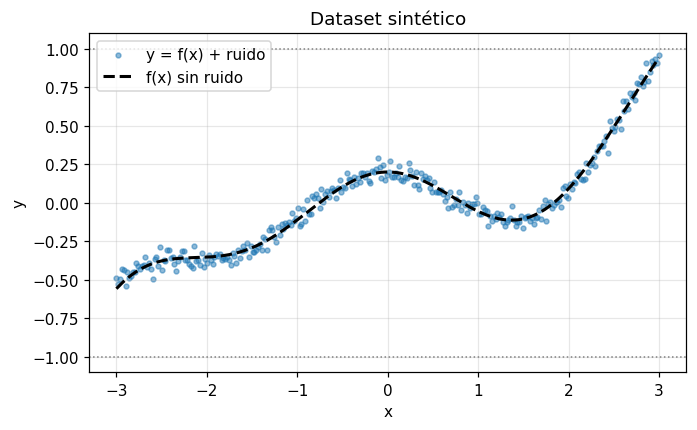

In [2]:
np.random.seed(0)

N = 300
x = np.linspace(-3, 3, N)

def patron_no_lineal(t):
    """Cúbica (tendencia con saturación) + coseno (ondulación no representable por una sola tanh)."""
    return 0.75 * (t / 3) ** 3 + 0.20 * np.cos(2 * t)

ruido = np.random.normal(0.0, 0.04, size=N)
y = patron_no_lineal(x) + ruido

print(f'n = {N}   x in [{x.min():.1f}, {x.max():.1f}]')
print(f'y in [{y.min():+.3f}, {y.max():+.3f}]   var(y) = {np.var(y):.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, s=10, alpha=0.5, label='y = f(x) + ruido')
ax.plot(x, patron_no_lineal(x), 'k--', lw=2, label='f(x) sin ruido')
ax.axhline(1, color='gray', ls=':', lw=1)
ax.axhline(-1, color='gray', ls=':', lw=1)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Dataset sintético')
ax.legend(); plt.show()

### Funciones base: costo, gradiente e inicialización compartida

Definimos una única función de gradiente que recibe un **subconjunto** `(xb, yb)` de los datos. Si le pasamos todo el dataset obtenemos el gradiente full-batch; si le pasamos un lote, el gradiente de mini-batch. Así GD, Adam full-batch y Adam mini-batch comparten **exactamente** la misma matemática, y cualquier diferencia que observemos es atribuible únicamente al optimizador.

La consigna pide inicializar $w$ y $b$ con `np.random.randn()` y **reutilizar los mismos valores en los tres optimizadores**, así que los fijamos una sola vez con semilla y los guardamos en constantes.

In [3]:
def J(w, b):
    """Costo MSE evaluado siempre sobre el dataset completo (para que las curvas sean comparables)."""
    yhat = np.tanh(w * x + b)
    return np.mean((yhat - y) ** 2)

def gradiente(w, b, xb, yb):
    """Gradiente de J respecto de (w, b) sobre el lote (xb, yb).

    dJ/dw = (2/m) * sum( (yhat - y) * (1 - yhat^2) * x )
    dJ/db = (2/m) * sum( (yhat - y) * (1 - yhat^2) )
    """
    m = len(xb)
    yhat = np.tanh(w * xb + b)
    delta = 2.0 * (yhat - yb) * (1.0 - yhat ** 2) / m   # término común a ambas derivadas
    dw = np.sum(delta * xb)
    db = np.sum(delta)
    return dw, db

# --- Inicialización aleatoria COMPARTIDA por los 3 optimizadores ---
np.random.seed(1)
W0 = np.random.randn()
B0 = np.random.randn()
print(f'Inicialización compartida:  w0 = {W0:+.4f}   b0 = {B0:+.4f}   J(w0,b0) = {J(W0, B0):.4f}')

# Óptimo de referencia: barrido fino de la superficie (nos sirve como "piso" del costo)
_W = np.linspace(-3, 3, 1201)
_B = np.linspace(-2, 2, 801)
_best = (np.inf, None)
for _w in _W:
    _a = np.tanh(_w * x[:, None] + _B[None, :])
    _Jv = np.mean((_a - y[:, None]) ** 2, axis=0)
    _i = _Jv.argmin()
    if _Jv[_i] < _best[0]:
        _best = (_Jv[_i], (_w, _B[_i]))
J_OPT, (W_OPT, B_OPT) = _best
print(f'Mínimo global (barrido):    w* = {W_OPT:+.4f}   b* = {B_OPT:+.4f}   J* = {J_OPT:.4f}')
print(f'R^2 máximo alcanzable por esta red de 1 conexión: {1 - J_OPT / np.var(y):.3f}')

g0 = gradiente(W0, B0, x, y)
print(f'\nNorma del gradiente en el punto inicial: |grad J(w0,b0)| = {np.hypot(*g0):.4e}')

Inicialización compartida:  w0 = +1.6243   b0 = -0.6118   J(w0,b0) = 0.5550


Mínimo global (barrido):    w* = +0.1500   b* = -0.0100   J* = 0.0364
R^2 máximo alcanzable por esta red de 1 conexión: 0.646

Norma del gradiente en el punto inicial: |grad J(w0,b0)| = 1.2833e-01


Tres números para tener presentes durante todo el análisis:

- **$J(w_0,b_0)\approx 0.555$**: el punto inicial cae en una zona **saturada** de la `tanh` ($w_0\approx1.62$ hace que $|z|$ llegue a $\sim 5$ en los extremos del dataset), es decir, arrancamos justo sobre la meseta de gradiente casi nulo. No es una trampa que armamos a propósito: `np.random.randn()` produce valores de ese orden con mucha frecuencia, y es exactamente el escenario donde la elección del optimizador importa.
- **$|\nabla J(w_0,b_0)|\approx 0.128$**: el gradiente es chico en términos *prácticos*, que es lo que importa. Con $\eta=0.01$ el primer paso mueve los parámetros apenas $1.3\times10^{-3}$, y necesitamos recorrer una distancia de $\approx 1.5$. A ese ritmo harían falta del orden de mil épocas, y tenemos cien.
- **$J^{*}\approx 0.0364$** con $w^{*}\approx 0.15$ y $b^{*}\approx -0.01$: el mejor ajuste posible explica ~65% de la varianza. Una sola conexión no puede hacer más, así que **el objetivo es 0.0364, no 0**.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [4]:
def gradiente_descendente(w0, b0, lr, epocas=EPOCAS):
    """GD clásico full-batch: una sola actualización de parámetros por época."""
    w, b = w0, b0
    hist_J = [J(w, b)]            # costo ANTES de la primera actualización (época 0)
    path_w, path_b = [w], [b]

    for _ in range(epocas):
        # 1) gradiente calculado con TODO el dataset
        dw, db = gradiente(w, b, x, y)
        # 2) paso en la dirección opuesta al gradiente
        w = w - lr * dw
        b = b - lr * db
        # 3) registro para las curvas y las trayectorias del punto 1d
        hist_J.append(J(w, b))
        path_w.append(w)
        path_b.append(b)

    return {'J': np.array(hist_J), 'w': np.array(path_w), 'b': np.array(path_b), 'updates': epocas}


res_gd = {lr: gradiente_descendente(W0, B0, lr) for lr in LRS}

for lr in LRS:
    r = res_gd[lr]
    print(f'GD  lr={lr:<6}  J_final = {r["J"][-1]:.4f}   (w,b)_final = ({r["w"][-1]:+.4f}, {r["b"][-1]:+.4f})')

GD  lr=0.1     J_final = 0.0364   (w,b)_final = (+0.1519, -0.0091)
GD  lr=0.01    J_final = 0.5358   (w,b)_final = (+1.4911, -0.5737)
GD  lr=0.001   J_final = 0.5533   (w,b)_final = (+1.6120, -0.6080)


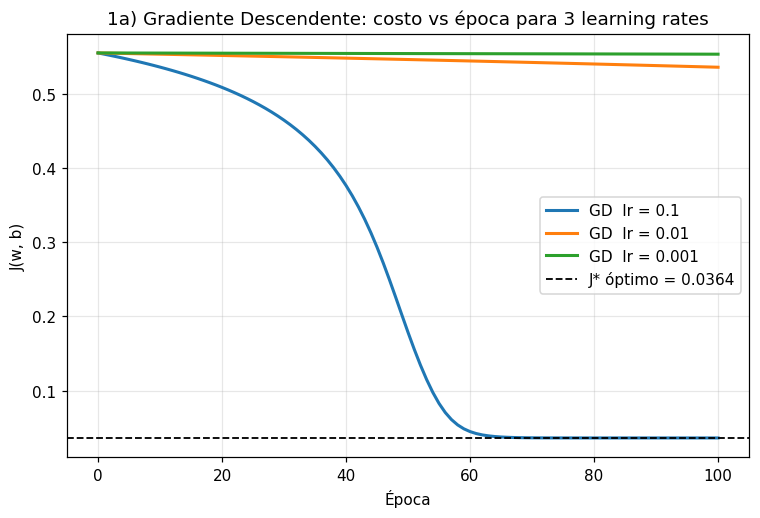

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for lr in LRS:
    ax.plot(res_gd[lr]['J'], color=COLOR_LR[lr], lw=2, label=f'GD  lr = {lr}')
ax.axhline(J_OPT, color='k', ls='--', lw=1.2, label=f'J* óptimo = {J_OPT:.4f}')
ax.set_xlabel('Época'); ax.set_ylabel('J(w, b)')
ax.set_title('1a) Gradiente Descendente: costo vs época para 3 learning rates')
ax.legend(); plt.show()

**Lectura del gráfico 1a.**

El resultado es más interesante que el clásico "el lr grande converge más rápido":

- **lr = 0.1** es el único que logra escapar. La curva se mantiene casi plana durante ~25 épocas y recién ahí cae de golpe hasta $J^{*}=0.0364$. Ese codo tan marcado es la firma de una **meseta**: mientras $|z|$ es grande, el factor $(1-\hat y^2)$ aplasta el gradiente; cuando $w$ por fin entra en la zona lineal de la `tanh` el gradiente recupera magnitud y la convergencia se vuelve casi instantánea.
- **lr = 0.01** y **lr = 0.001** quedan prácticamente congelados en $J\approx 0.54$ y $J\approx 0.55$: en 100 épocas apenas mueven los parámetros desde $(1.624,\,-0.612)$.

Conviene ser precisos con el diagnóstico: **GD no quedó atrapado en un mínimo local, quedó atrapado en una meseta**. Lo verificamos en la celda siguiente dejándolo correr 20.000 épocas: con los tres learning rates termina llegando al mismo $J^{*}$. El problema no es que el algoritmo no sepa hacia dónde ir, sino que el paso efectivo $\eta\cdot\nabla J$ es diminuto porque $\nabla J$ lo es. Esta distinción es importante porque cambia el remedio: si fuera un mínimo local habría que cambiar la inicialización o agregar ruido; siendo una meseta, alcanza con un optimizador que **reescale** el gradiente, que es precisamente lo que hace Adam.

In [6]:
print('Verificación: ¿meseta o mínimo local? -> dejamos correr GD 20.000 épocas\n')

tabla_meseta = []
for lr in LRS:
    r_largo = gradiente_descendente(W0, B0, lr, epocas=20000)
    tabla_meseta.append({
        'lr': lr,
        'J @ 100 épocas': round(res_gd[lr]['J'][-1], 4),
        'J @ 20.000 épocas': round(r_largo['J'][-1], 4),
        'w final @ 20.000': round(r_largo['w'][-1], 4),
    })

display(pd.DataFrame(tabla_meseta))
print(f'\nJ* de referencia = {J_OPT:.4f}  ->  con suficientes épocas los 3 learning rates llegan al mismo mínimo.')
print('La superficie NO tiene un mínimo local espurio: tiene una meseta de gradiente evanescente.')

Verificación: ¿meseta o mínimo local? -> dejamos correr GD 20.000 épocas



,lr,J @ 100 épocas,J @ 20.000 épocas,w final @ 20.000
0,0.100,0.0364,0.0364,0.1519
1,0.010,0.5358,0.0364,0.1519
2,0.001,0.5533,0.0364,0.1519



J* de referencia = 0.0364  ->  con suficientes épocas los 3 learning rates llegan al mismo mínimo.
La superficie NO tiene un mínimo local espurio: tiene una meseta de gradiente evanescente.


### 1b) Implementación de Adam (2 punto)
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno full-batch y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

Implementamos **una sola función** `adam(...)` con un parámetro `batch_size`:

- `batch_size=None` → **full-batch**: un lote por época, es decir 1 actualización por época (comparable 1 a 1 con GD).
- `batch_size=32` → **mini-batch**: el dataset se baraja en cada época y se recorre en lotes de 32; con $n=300$ eso da **10 actualizaciones por época**.

Detalles de implementación que importan y que es fácil equivocar:

- El contador $t$ de la corrección de sesgo se incrementa **por actualización**, no por época. En mini-batch eso significa que $t$ llega a 1000 y no a 100, así que la corrección $1-\beta_1^{t}$ deja de tener efecto mucho antes.
- Los momentos $m$ y $v$ se inicializan en 0 y **no** se reinician entre épocas: la memoria del gradiente es continua a lo largo de todo el entrenamiento.
- Usamos los valores por defecto del paper de Kingma & Ba, *Adam: A Method for Stochastic Optimization*, ICLR 2015 ([arXiv:1412.6980](https://arxiv.org/abs/1412.6980)): $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$.
- El costo se registra siempre sobre el **dataset completo** al final de cada época, para que las curvas de los tres optimizadores vivan en el mismo eje y sean comparables.

In [7]:
BATCH_SIZE = 32
BETA1, BETA2, EPS = 0.9, 0.999, 1e-8

def adam(w0, b0, lr, epocas=EPOCAS, batch_size=None, seed=7):
    """Adam implementado desde cero.

    batch_size=None -> full-batch  (1 update por época)
    batch_size=k    -> mini-batch  (ceil(n/k) updates por época, con shuffle en cada época)
    """
    w, b = w0, b0
    m_w = m_b = 0.0          # 1er momento: media móvil del gradiente
    v_w = v_b = 0.0          # 2do momento: media móvil del gradiente al cuadrado
    t = 0                    # contador de ACTUALIZACIONES (no de épocas)

    rng = np.random.default_rng(seed)
    hist_J = [J(w, b)]
    path_w, path_b = [w], [b]

    for _ in range(epocas):
        # --- armado de los lotes de la época ---
        if batch_size is None:
            lotes = [np.arange(len(x))]
        else:
            idx = rng.permutation(len(x))                       # shuffle en cada época
            lotes = np.array_split(idx, int(np.ceil(len(x) / batch_size)))

        for bi in lotes:
            t += 1
            dw, db = gradiente(w, b, x[bi], y[bi])

            # 1) momentos móviles
            m_w = BETA1 * m_w + (1 - BETA1) * dw
            m_b = BETA1 * m_b + (1 - BETA1) * db
            v_w = BETA2 * v_w + (1 - BETA2) * (dw * dw)
            v_b = BETA2 * v_b + (1 - BETA2) * (db * db)

            # 2) corrección del sesgo hacia cero de los primeros pasos
            m_w_hat = m_w / (1 - BETA1 ** t)
            m_b_hat = m_b / (1 - BETA1 ** t)
            v_w_hat = v_w / (1 - BETA2 ** t)
            v_b_hat = v_b / (1 - BETA2 ** t)

            # 3) paso adaptativo, independiente para cada parámetro
            w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + EPS)
            b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + EPS)

        hist_J.append(J(w, b))
        path_w.append(w)
        path_b.append(b)

    return {'J': np.array(hist_J), 'w': np.array(path_w), 'b': np.array(path_b), 'updates': t}


res_fb = {lr: adam(W0, B0, lr, batch_size=None)       for lr in LRS}
res_mb = {lr: adam(W0, B0, lr, batch_size=BATCH_SIZE) for lr in LRS}

print(f'batch_size = {BATCH_SIZE}  ->  {res_mb[0.1]["updates"]} actualizaciones en {EPOCAS} épocas '
      f'(vs {res_fb[0.1]["updates"]} en full-batch)\n')
for lr in LRS:
    print(f'lr={lr:<6}  Adam full-batch J_final = {res_fb[lr]["J"][-1]:.4f}   |   '
          f'Adam mini-batch J_final = {res_mb[lr]["J"][-1]:.4f}')

batch_size = 32  ->  1000 actualizaciones en 100 épocas (vs 100 en full-batch)

lr=0.1     Adam full-batch J_final = 0.0364   |   Adam mini-batch J_final = 0.0383
lr=0.01    Adam full-batch J_final = 0.1191   |   Adam mini-batch J_final = 0.0364
lr=0.001   Adam full-batch J_final = 0.5377   |   Adam mini-batch J_final = 0.0780


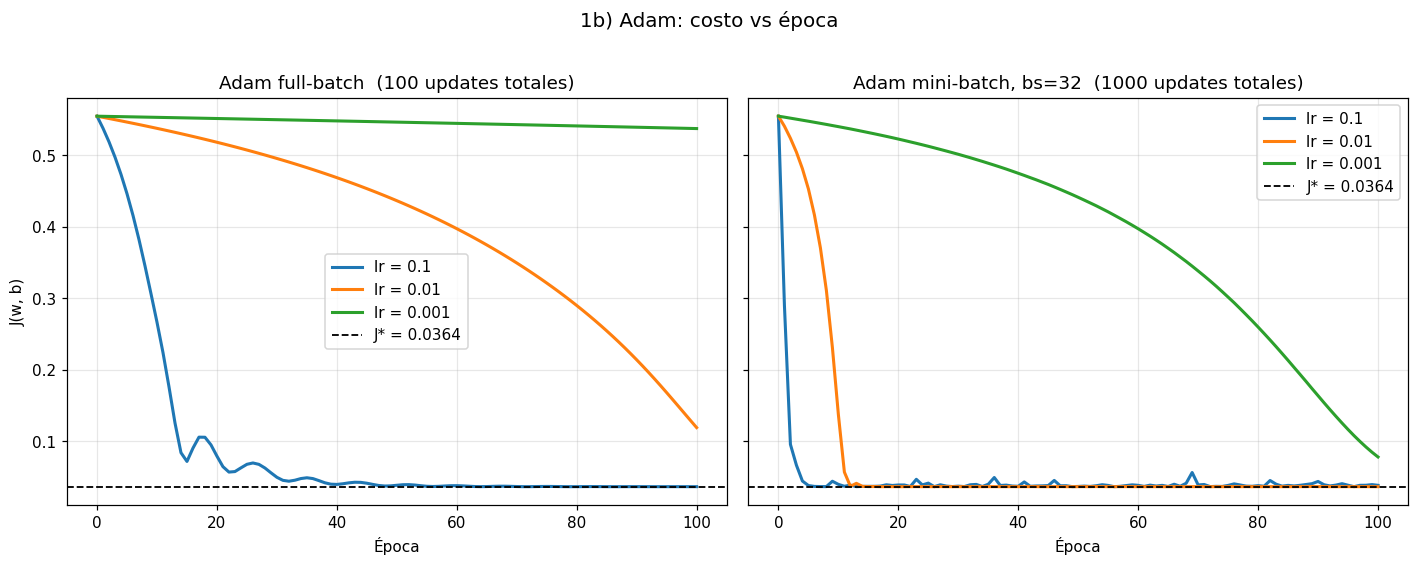

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for lr in LRS:
    axes[0].plot(res_fb[lr]['J'], color=COLOR_LR[lr], lw=2, label=f'lr = {lr}')
    axes[1].plot(res_mb[lr]['J'], color=COLOR_LR[lr], lw=2, label=f'lr = {lr}')

titulos = [f'Adam full-batch  ({EPOCAS} updates totales)',
           f'Adam mini-batch, bs={BATCH_SIZE}  ({res_mb[0.1]["updates"]} updates totales)']
for ax, titulo in zip(axes, titulos):
    ax.axhline(J_OPT, color='k', ls='--', lw=1.2, label=f'J* = {J_OPT:.4f}')
    ax.set_xlabel('Época'); ax.set_title(titulo); ax.legend()
axes[0].set_ylabel('J(w, b)')

fig.suptitle('1b) Adam: costo vs época', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

**Lectura del gráfico 1b.**

*Adam full-batch.* Con **lr = 0.1** atraviesa la meseta y aterriza en $J^{*}$; con **lr = 0.01** también escapa, pero se queda corto ($J\approx0.119$, con $w=0.37$ frente al óptimo $w^{*}=0.15$) cuando se agotan las 100 épocas; con **lr = 0.001** queda tan varado como GD. Esto se entiende mirando la regla de actualización: cuando el gradiente mantiene el signo, $\hat m_t/\sqrt{\hat v_t}$ es una cantidad **adimensional de módulo cercano a 1**, de modo que el desplazamiento por paso es del orden de $\eta$ **sin importar cuán chico sea el gradiente**. Para recorrer la distancia $|w_0-w^{*}|\approx1.47$ hacen falta entonces del orden de $1.47/\eta$ pasos: ~15 con $\eta=0.1$, ~150 con $\eta=0.01$ (más que las 100 épocas disponibles) y ~1500 con $\eta=0.001$. Es un argumento de orden de magnitud, no exacto —en la práctica Adam tarda unas 30 épocas con $\eta=0.1$ en vez de 15, porque al principio el gradiente cambia de dirección y el cociente no alcanza su módulo máximo— pero predice correctamente cuáles de las tres configuraciones llegan y cuáles no.

Este es, en el fondo, el mecanismo que hace a Adam útil: **desacopla el tamaño del paso de la magnitud del gradiente**. En una meseta eso es exactamente lo que se necesita. El precio es que el learning rate de Adam ya no significa lo mismo que en GD: pasa a ser, aproximadamente, "cuánto me muevo en el espacio de parámetros por paso", y por eso $\eta=0.001$ (el valor por defecto que todo el mundo usa en redes profundas) resulta acá **demasiado chico**.

*Adam mini-batch.* Domina en los tres learning rates. Con **lr = 0.01** converge a $J^{*}$ y con **lr = 0.001**, donde tanto GD como Adam full-batch fracasan, igual llega a $J\approx0.078$. La razón es doble y conviene separarla porque se confunden seguido:

1. **Cantidad de actualizaciones (el efecto grande).** Hace 10 pasos por época, así que al llegar a la época 100 ya acumuló 1000 pasos. Aplicando la misma cuenta de arriba, con $\eta=0.001$ recorre $\approx 1000\times0.001 = 1.0$ en el espacio de parámetros, que es del orden de lo que necesita. Es decir, buena parte de su ventaja es simplemente **presupuesto de actualizaciones**, no una virtud intrínseca del muestreo.
2. **Ruido del muestreo (el efecto fino).** El gradiente de un lote de 32 no apunta exactamente igual que el full-batch. Sobre una meseta eso ayuda: agrega una componente aleatoria que impide que $v_t$ colapse a un valor tan chico. La contracara aparece cuando el paso es grande en relación al tamaño del valle: con $\eta=0.1$ el mini-batch no se clava en $J^{*}$ sino que termina en $0.0383$, apenas por encima, porque cada lote tira un poco para su lado y Adam nunca reduce su paso por sí solo. Con $\eta=0.01$, en cambio, el paso es lo bastante chico como para que el ruido no lo saque del mínimo y alcanza exactamente $J^{*}=0.0364$. O sea que el ruido del mini-batch **ayuda a salir de la meseta y molesta al llegar al fondo**, y cuál de los dos efectos domina depende de $\eta$.

Esa distinción importa para no sacar conclusiones tramposas: comparando "por época", el mini-batch parece muy superior, pero **no es una comparación justa en costo computacional**. Lo cuantificamos en 1c.

### 1c) Comparativa de optimizadores (0.5 puntos)
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

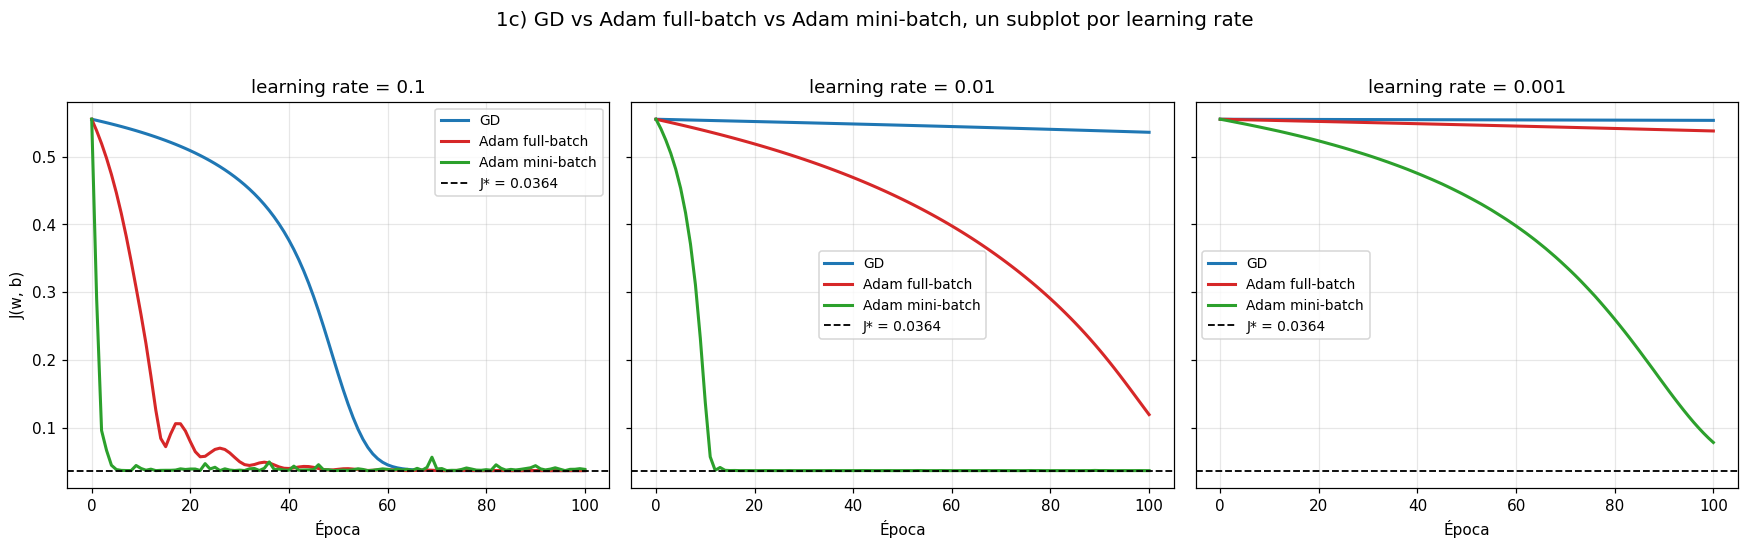

In [9]:
RESULTADOS = {'GD': res_gd, 'Adam full-batch': res_fb, 'Adam mini-batch': res_mb}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, lr in zip(axes, LRS):
    for nombre, res in RESULTADOS.items():
        ax.plot(res[lr]['J'], color=COLOR_OPT[nombre], lw=2, label=nombre)
    ax.axhline(J_OPT, color='k', ls='--', lw=1.2, label=f'J* = {J_OPT:.4f}')
    ax.set_title(f'learning rate = {lr}')
    ax.set_xlabel('Época')
    ax.legend(fontsize=9)
axes[0].set_ylabel('J(w, b)')
fig.suptitle('1c) GD vs Adam full-batch vs Adam mini-batch, un subplot por learning rate', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

El gráfico anterior compara **por época**, que es lo que pide la consigna, pero esa unidad favorece de entrada al mini-batch porque hace 10 veces más actualizaciones dentro de cada época. Para que la comparación sea honesta agregamos el mismo experimento medido en **número de actualizaciones de parámetros** (eje logarítmico), que es la unidad en la que los tres algoritmos cuestan lo mismo por paso en una red de este tamaño.

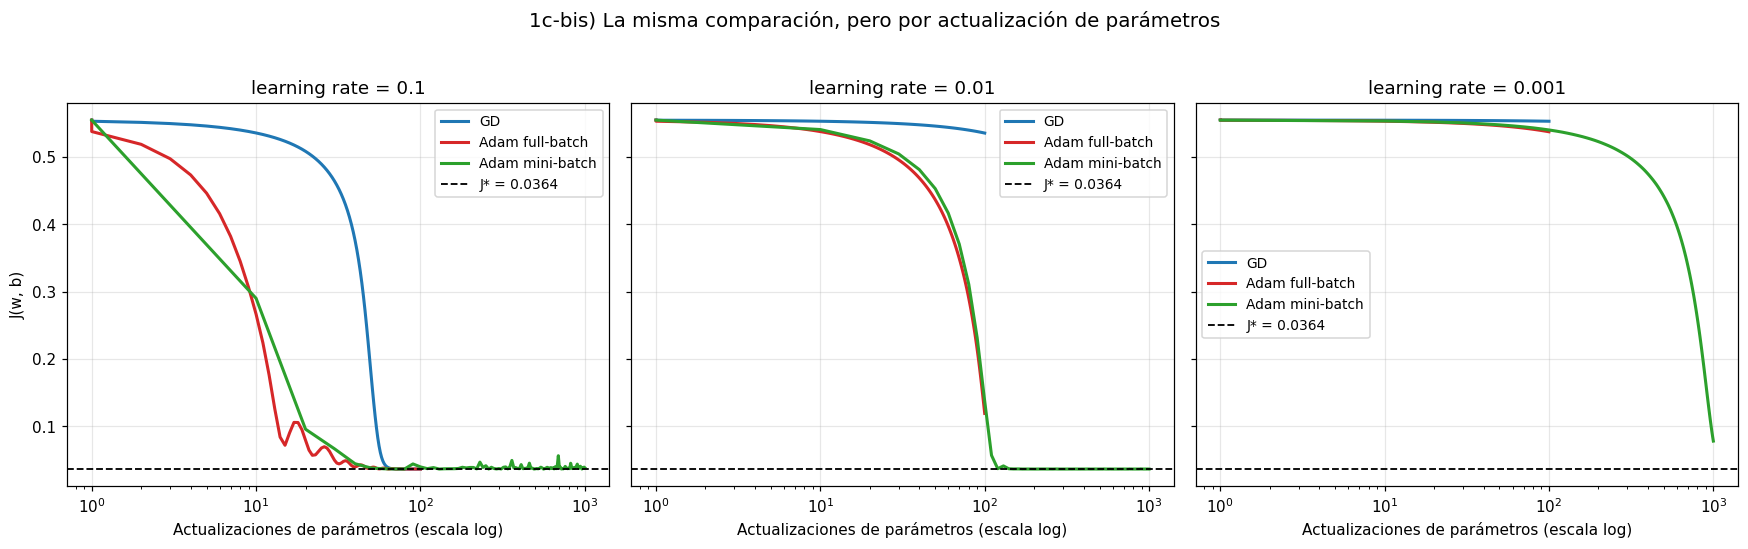

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, lr in zip(axes, LRS):
    for nombre, res in RESULTADOS.items():
        n_upd = res[lr]['updates']
        pasos_por_epoca = n_upd / EPOCAS
        eje = np.arange(len(res[lr]['J'])) * pasos_por_epoca
        ax.plot(np.maximum(eje, 1), res[lr]['J'], color=COLOR_OPT[nombre], lw=2, label=nombre)
    ax.axhline(J_OPT, color='k', ls='--', lw=1.2, label=f'J* = {J_OPT:.4f}')
    ax.set_xscale('log')
    ax.set_title(f'learning rate = {lr}')
    ax.set_xlabel('Actualizaciones de parámetros (escala log)')
    ax.legend(fontsize=9)
axes[0].set_ylabel('J(w, b)')
fig.suptitle('1c-bis) La misma comparación, pero por actualización de parámetros', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

In [11]:
# --- Tabla comparativa cuantitativa ---
UMBRAL = 0.05   # 1.37 * J*, lo tomamos como "convergido"

filas = []
for nombre, res in RESULTADOS.items():
    for lr in LRS:
        r = res[lr]
        Jh = r['J']
        pasos_por_epoca = r['updates'] / EPOCAS
        llego = np.where(Jh < UMBRAL)[0]
        ep_conv = int(llego[0]) if len(llego) else None
        filas.append({
            'Optimizador': nombre,
            'lr': lr,
            'J inicial': round(Jh[0], 4),
            'J final': round(Jh[-1], 4),
            'R2 final': round(1 - Jh[-1] / np.var(y), 3),
            f'Época a J<{UMBRAL}': ep_conv if ep_conv is not None else 'no llega',
            f'Updates a J<{UMBRAL}': int(ep_conv * pasos_por_epoca) if ep_conv is not None else 'no llega',
            'w final': round(r['w'][-1], 4),
            'b final': round(r['b'][-1], 4),
            'Updates totales': r['updates'],
        })

tabla_1c = pd.DataFrame(filas)
display(tabla_1c.style.hide(axis='index').set_caption('Tabla 1c: resumen cuantitativo de los 9 entrenamientos'))

Optimizador,lr,J inicial,J final,R2 final,Época a J<0.05,Updates a J<0.05,w final,b final,Updates totales
GD,0.100000,0.555000,0.036400,0.646000,59,59,0.151900,-0.009100,100
GD,0.010000,0.555000,0.535800,-4.210000,no llega,no llega,1.491100,-0.573700,100
GD,0.001000,0.555000,0.553300,-4.381000,no llega,no llega,1.612000,-0.608000,100
Adam full-batch,0.100000,0.555000,0.036400,0.646000,30,30,0.151700,-0.007100,100
Adam full-batch,0.010000,0.555000,0.119100,-0.158000,no llega,no llega,0.369300,0.061800,100
Adam full-batch,0.001000,0.555000,0.537700,-4.229000,no llega,no llega,1.522200,-0.510600,100
Adam mini-batch,0.100000,0.555000,0.038300,0.628000,4,40,0.171900,0.023500,1000
Adam mini-batch,0.010000,0.555000,0.036400,0.646000,12,120,0.152100,-0.007900,1000
Adam mini-batch,0.001000,0.555000,0.078000,0.242000,no llega,no llega,0.293300,-0.074000,1000


In [12]:
# --- Tabla pivote: J final por optimizador y learning rate ---
pivote = tabla_1c.pivot(index='Optimizador', columns='lr', values='J final')
pivote = pivote.loc[['GD', 'Adam full-batch', 'Adam mini-batch'], LRS]
print('J final (objetivo: J* = %.4f)\n' % J_OPT)
display(pivote)

J final (objetivo: J* = 0.0364)



lr,0.100,0.010,0.001
Optimizador,,,
GD,0.0364,0.5358,0.5533
Adam full-batch,0.0364,0.1191,0.5377
Adam mini-batch,0.0383,0.0364,0.0780


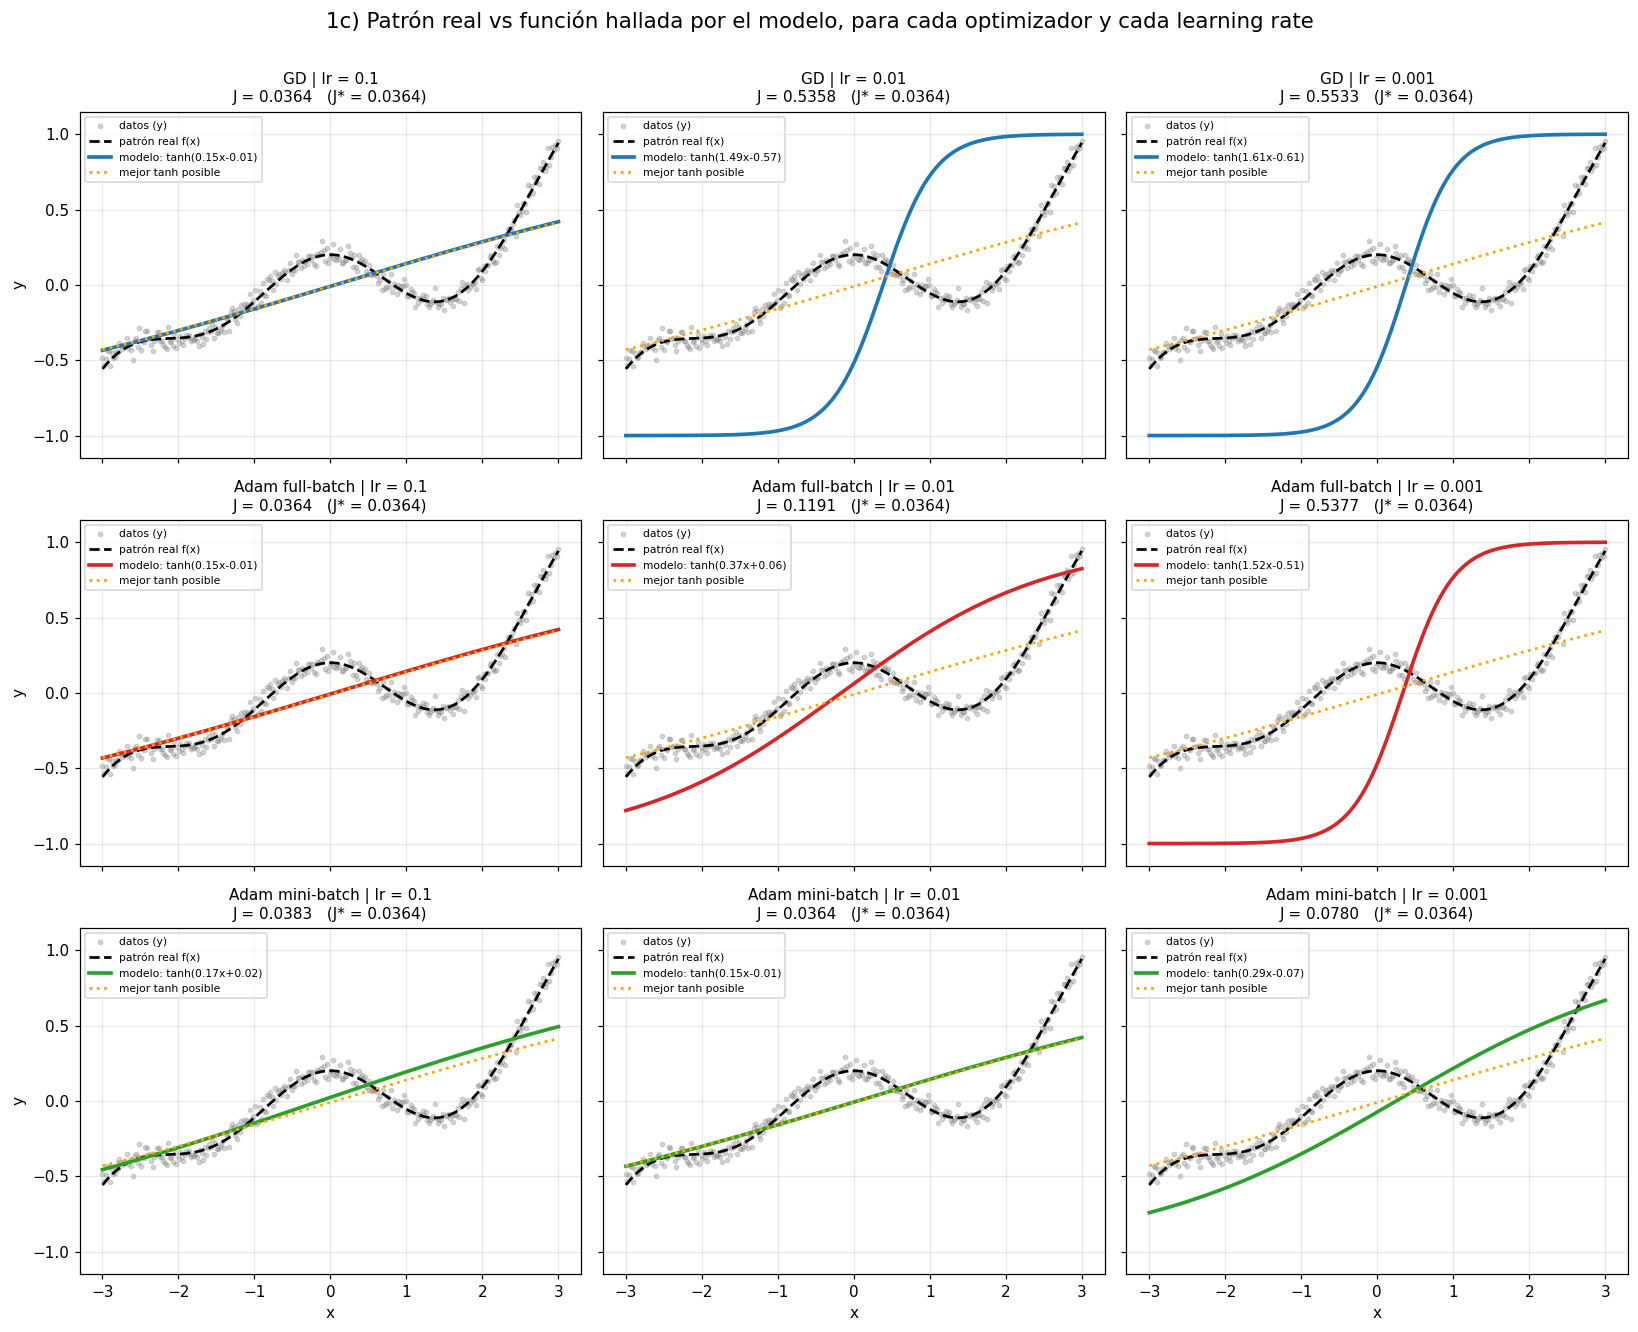

In [13]:
# --- 9 subplots: patrón real vs función aprendida por el modelo ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

x_fino = np.linspace(-3, 3, 400)
for i, (nombre, res) in enumerate(RESULTADOS.items()):
    for j, lr in enumerate(LRS):
        ax = axes[i, j]
        w_f, b_f = res[lr]['w'][-1], res[lr]['b'][-1]
        Jf = res[lr]['J'][-1]

        ax.scatter(x, y, s=8, alpha=0.30, color='gray', label='datos (y)')
        ax.plot(x_fino, patron_no_lineal(x_fino), 'k--', lw=1.8, label='patrón real f(x)')
        ax.plot(x_fino, np.tanh(w_f * x_fino + b_f), color=COLOR_OPT[nombre], lw=2.4,
                label=f'modelo: tanh({w_f:.2f}x{b_f:+.2f})')
        ax.plot(x_fino, np.tanh(W_OPT * x_fino + B_OPT), color='orange', ls=':', lw=1.8,
                label='mejor tanh posible')

        ax.set_title(f'{nombre} | lr = {lr}\nJ = {Jf:.4f}   (J* = {J_OPT:.4f})', fontsize=10)
        ax.set_ylim(-1.15, 1.15)
        if i == 2: ax.set_xlabel('x')
        if j == 0: ax.set_ylabel('y')
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('1c) Patrón real vs función hallada por el modelo, para cada optimizador y cada learning rate',
             y=1.005, fontsize=14)
plt.tight_layout(); plt.show()

### Conclusiones analíticas de la Pregunta 1 (1c)

**1. El resultado final no ordena a los optimizadores: los ordena la combinación optimizador × learning rate.**

Mirando la tabla pivote, ningún optimizador gana en las tres columnas por la misma razón. Con $\eta=0.1$ los tres llegan a $J^{*}$ y GD es incluso marginalmente mejor que Adam mini-batch ($0.0364$ vs $0.0383$). Con $\eta=0.01$ el orden es mini-batch $\gg$ full-batch $\gg$ GD. Con $\eta=0.001$ sólo el mini-batch se acerca. La conclusión práctica no es "Adam es mejor que GD", sino que **Adam es mucho menos sensible a la elección del learning rate**: su peor resultado con $\eta$ mal elegido sigue siendo mejor que el de GD, y su rango de $\eta$ utilizables es más ancho. En un problema real, donde no conocemos $J^{*}$ de antemano y no podemos hacer un barrido exhaustivo, esa robustez es exactamente lo que se compra al usar Adam.

**2. La velocidad de convergencia cambia según la unidad en que se mida, y hay que decir cuál se usa.**

Por **época** (columna "Época a J<0.05") el mini-batch es el más rápido en todos los casos: con $\eta=0.1$ converge en 4 épocas contra 30 de Adam full-batch y 59 de GD. Pero por **actualización de parámetros** (columna "Updates a J<0.05") el orden cambia: Adam full-batch necesita 30 updates y el mini-batch 40. Es decir, **el mini-batch no es más eficiente por paso; da más pasos**. Lo que sí sigue siendo cierto es que cada uno de sus pasos cuesta ~10 veces menos en operaciones (procesa 32 muestras en lugar de 300), así que en tiempo de cómputo real igual gana; pero el mecanismo es ése, y no una propiedad mágica del muestreo aleatorio. Nos parece importante señalarlo porque el gráfico "por época" invita a la conclusión equivocada, y en la Pregunta 2 la elección del `batch_size` se apoya exactamente en este razonamiento.

**3. La forma de las curvas dice más que el valor final.**

Las curvas de GD tienen forma de **codo**: plano larguísimo y después caída abrupta. Las de Adam tienen forma de **rampa**: bajada aproximadamente lineal desde la primera época. Eso es la consecuencia directa de la normalización por $\sqrt{\hat v_t}$, que convierte el avance en el espacio de parámetros en algo casi constante e igual a $\eta$ por paso, independientemente de la pendiente local. Dicho de otro modo: **GD mide la distancia al mínimo en unidades de gradiente y Adam la mide en unidades de $\eta$**. Cuando el gradiente es informativo (superficie bien condicionada) la primera estrategia es mejor; cuando el gradiente está aplastado por saturación, la segunda es la única que avanza.

**4. Adam mini-batch converge pero no siempre se queda quieto, y el culpable es $\eta$.**

Con $\eta=0.1$ el mini-batch se detiene en $0.0383$, apenas por encima de $J^{*}=0.0364$, y con una oscilación visible de baja amplitud; con $\eta=0.01$, en cambio, alcanza exactamente $J^{*}$. GD y Adam full-batch con $\eta=0.1$ también se clavan en $J^{*}$. La explicación es la misma que dimos en 1b: el gradiente de cada lote es un estimador ruidoso del verdadero y Adam no reduce su paso automáticamente, así que el iterado termina haciendo un paseo aleatorio en una vecindad del mínimo **cuyo radio es proporcional a $\eta$**. Con $\eta=0.1$ ese radio es apreciable frente al ancho del valle; con $\eta=0.01$ no lo es. Es decir que el mini-batch paga un pequeño impuesto de ruido en el óptimo, y ese impuesto se puede regular bajando $\eta$ o, en un problema real, con un *scheduler* que lo decaiga sobre el final o con *early stopping*. Es exactamente el mismo fenómeno que vamos a volver a ver en la Pregunta 2.

**5. El límite lo pone la capacidad del modelo, no el optimizador.**

En los 9 subplots se ve que **ninguna** de las curvas ajustadas reproduce la ondulación del coseno: las que convergieron ($J=0.0364$) coinciden exactamente con "la mejor `tanh` posible" (línea naranja punteada) y el $R^2$ tope es 0.646. Es decir: **el optimizador sólo puede llevarnos hasta el mejor punto de la familia de funciones que el modelo puede representar**; con una sola conexión sináptica esa familia es el conjunto de sigmoides monótonas, y ninguna de ellas oscila.

Hay un detalle de esas curvas que va más allá de lo que pedía la consigna y que nos parece la observación más interesante del punto. La solución óptima es $\tanh(0.15x - 0.01)$, y como $x\in[-3,3]$, el argumento nunca sale de $[-0.46,\,0.46]$, que es justo el tramo donde $\tanh(z)\approx z$. **La curva ajustada es, para todos los efectos prácticos, una recta.** O sea que el mejor uso que esta red puede darle a su no linealidad es no usarla: el óptimo global consiste en replegarse a la zona lineal de la activación y hacer una regresión lineal simple. Que la mejor estrategia de un modelo no lineal sea comportarse linealmente es la forma más contundente de decir que le falta capacidad. Para capturar el coseno haría falta una capa oculta con varias neuronas, cada una saturando en una zona distinta de $x$.

Esta es la moraleja que nos llevamos de cara a la Pregunta 2: primero hay que darle a la red la capacidad y las features necesarias, y recién después discutir el optimizador. Curiosamente, en la Pregunta 2 nos vamos a encontrar con el fenómeno espejo —una red con capacidad de sobra sobre un problema esencialmente lineal— y la conclusión práctica va a ser la misma: el modelo se acomoda al problema, no al revés.

**6. Un matiz sobre los subplots que fracasaron.**

Los casos que no convergieron (GD con $\eta\in\{0.01,\,0.001\}$ y Adam full-batch con $\eta=0.001$) muestran una curva que ya está saturada: una función escalón suavizada que vale $\approx -1$ a la izquierda y $\approx +1$ a la derecha. No es que el modelo "no aprendió nada": es que arrancó en esa configuración y el optimizador no pudo sacarlo. El $R^2$ correspondiente es negativo, o sea que predice **peor que la media** de $y$. Esto ilustra que un entrenamiento fallido no da un modelo mediocre, da un modelo inservible, y que en la práctica conviene monitorear la curva de costo desde las primeras épocas para detectar estos casos temprano.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

**Learning rate elegido: $\eta = 0.01$.**

Es el único de los tres en el que los tres optimizadores terminan en **lugares distintos** del espacio de parámetros, así que es donde la diferencia se ve mejor:

- con $\eta=0.1$ los tres llegan al mismo punto y las trayectorias se superponen casi por completo;
- con $\eta=0.001$ dos de los tres no se mueven y el gráfico queda vacío;
- con $\eta=0.01$ GD queda quieto en el borde de la meseta, Adam full-batch avanza a mitad de camino y Adam mini-batch llega al fondo. Los tres estados posibles conviven en la misma figura.

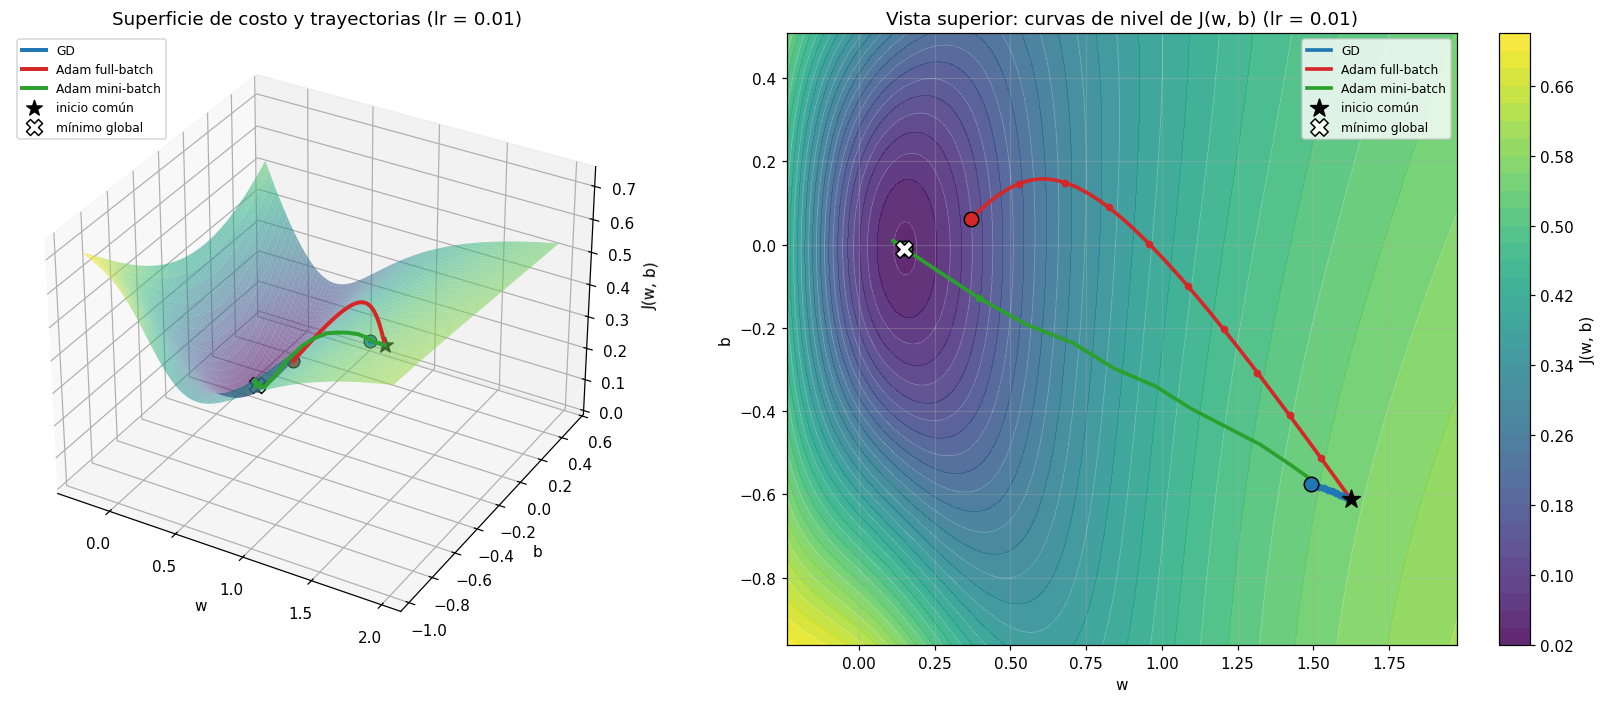

In [14]:
LR_3D = 0.01

# --- Malla de la superficie de costo ---
pad = 0.35
todas_w = np.concatenate([RESULTADOS[k][LR_3D]['w'] for k in RESULTADOS] + [[W_OPT]])
todas_b = np.concatenate([RESULTADOS[k][LR_3D]['b'] for k in RESULTADOS] + [[B_OPT]])
w_min, w_max = todas_w.min() - pad, todas_w.max() + pad
b_min, b_max = todas_b.min() - pad, todas_b.max() + pad

W_g = np.linspace(w_min, w_max, 160)
B_g = np.linspace(b_min, b_max, 160)
WW, BB = np.meshgrid(W_g, B_g)
JJ = np.zeros_like(WW)
for i in range(WW.shape[0]):
    a_grid = np.tanh(WW[i][None, :] * x[:, None] + BB[i][None, :])
    JJ[i] = np.mean((a_grid - y[:, None]) ** 2, axis=0)

fig = plt.figure(figsize=(16, 6.5))

# ---------- Panel 3D ----------
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
ax3d.plot_surface(WW, BB, JJ, cmap='viridis', alpha=0.55, linewidth=0, antialiased=True, rstride=2, cstride=2)

for nombre, res in RESULTADOS.items():
    pw, pb = res[LR_3D]['w'], res[LR_3D]['b']
    pJ = np.array([J(a, b) for a, b in zip(pw, pb)])
    ax3d.plot(pw, pb, pJ, color=COLOR_OPT[nombre], lw=2.6, label=nombre, zorder=10)
    ax3d.scatter([pw[-1]], [pb[-1]], [pJ[-1]], color=COLOR_OPT[nombre],
                 s=70, edgecolor='k', linewidth=0.8, zorder=11)

ax3d.scatter([W0], [B0], [J(W0, B0)], color='black', s=110, marker='*', zorder=12, label='inicio común')
ax3d.scatter([W_OPT], [B_OPT], [J_OPT], color='white', s=110, marker='X',
             edgecolor='k', linewidth=1.0, zorder=12, label='mínimo global')

ax3d.set_xlabel('w'); ax3d.set_ylabel('b'); ax3d.set_zlabel('J(w, b)')
ax3d.view_init(elev=32, azim=-60)
ax3d.set_title(f'Superficie de costo y trayectorias (lr = {LR_3D})')
ax3d.legend(fontsize=8, loc='upper left')

# ---------- Panel de contornos ----------
ax2d = fig.add_subplot(1, 2, 2)
cs = ax2d.contourf(WW, BB, JJ, levels=35, cmap='viridis', alpha=0.85)
ax2d.contour(WW, BB, JJ, levels=18, colors='white', linewidths=0.4, alpha=0.5)
fig.colorbar(cs, ax=ax2d, label='J(w, b)')

for nombre, res in RESULTADOS.items():
    pw, pb = res[LR_3D]['w'], res[LR_3D]['b']
    ax2d.plot(pw, pb, color=COLOR_OPT[nombre], lw=2.4, label=nombre)
    ax2d.scatter(pw[::10], pb[::10], color=COLOR_OPT[nombre], s=16, zorder=5)
    ax2d.scatter([pw[-1]], [pb[-1]], color=COLOR_OPT[nombre], s=90, edgecolor='k', zorder=6)

ax2d.scatter([W0], [B0], color='black', s=150, marker='*', zorder=7, label='inicio común')
ax2d.scatter([W_OPT], [B_OPT], color='white', s=130, marker='X', edgecolor='k', zorder=7, label='mínimo global')
ax2d.set_xlabel('w'); ax2d.set_ylabel('b')
ax2d.set_title(f'Vista superior: curvas de nivel de J(w, b) (lr = {LR_3D})')
ax2d.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [15]:
# --- Cuantificación del movimiento en el espacio de parámetros ---
filas = []
for nombre, res in RESULTADOS.items():
    pw, pb = res[LR_3D]['w'], res[LR_3D]['b']
    pasos = np.hypot(np.diff(pw), np.diff(pb))
    dist_recorrida = pasos.sum()
    dist_neta = np.hypot(pw[-1] - pw[0], pb[-1] - pb[0])
    dist_al_optimo = np.hypot(pw[-1] - W_OPT, pb[-1] - B_OPT)
    filas.append({
        'Optimizador': nombre,
        'Distancia recorrida': round(dist_recorrida, 4),
        'Desplazamiento neto': round(dist_neta, 4),
        'Rectitud (neto/recorrido)': round(dist_neta / dist_recorrida, 3) if dist_recorrida > 0 else np.nan,
        'Desplazamiento medio por época': f'{pasos.mean():.2e}',
        'Desplazamiento máx. por época': f'{pasos.max():.2e}',
        'Distancia final al óptimo': round(dist_al_optimo, 4),
    })

print(f'Movimiento en el espacio de parámetros (lr = {LR_3D}, {EPOCAS} épocas)\n')
display(pd.DataFrame(filas).style.hide(axis='index'))

# --- ¿Está mal condicionada la superficie cerca del óptimo? ---
h = 1e-4
H = np.array([
    [(J(W_OPT + h, B_OPT) - 2 * J(W_OPT, B_OPT) + J(W_OPT - h, B_OPT)) / h ** 2,
     (J(W_OPT + h, B_OPT + h) - J(W_OPT + h, B_OPT - h)
      - J(W_OPT - h, B_OPT + h) + J(W_OPT - h, B_OPT - h)) / (4 * h ** 2)],
    [0, (J(W_OPT, B_OPT + h) - 2 * J(W_OPT, B_OPT) + J(W_OPT, B_OPT - h)) / h ** 2]])
H[1, 0] = H[0, 1]
autovalores = np.linalg.eigvalsh(H)
print(f'\nHessiano de J en el mínimo:\n{H.round(3)}')
print(f'Autovalores: {autovalores.round(3)}  ->  número de condición = {autovalores.max()/autovalores.min():.2f}')

Movimiento en el espacio de parámetros (lr = 0.01, 100 épocas)



Optimizador,Distancia recorrida,Desplazamiento neto,Rectitud (neto/recorrido),Desplazamiento medio por época,Desplazamiento máx. por época,Distancia final al óptimo
GD,0.138500,0.138500,1.000000,1.39e-03,1.50e-03,1.454800
Adam full-batch,1.557000,1.424300,0.915000,1.56e-02,1.94e-02,0.230800
Adam mini-batch,2.297800,1.591300,0.693000,2.30e-02,1.69e-01,0.002900



Hessiano de J en el mínimo:
[[5.046 0.045]
 [0.045 1.763]]
Autovalores: [1.762 5.046]  ->  número de condición = 2.86


### Análisis de las trayectorias (1d)

**Cómo se mueve cada uno.**

- **GD (azul).** Prácticamente no se mueve: recorre $\approx 0.14$ en el espacio de parámetros en 100 épocas, con un desplazamiento por época del orden de $1.4\times10^{-3}$, y termina a distancia $1.45$ del óptimo. En la vista de contornos se ve como un punto grueso pegado al asterisco de inicio. Está sobre una zona donde las curvas de nivel están **muy separadas** (superficie casi plana) y, como su paso es proporcional al gradiente, el paso es casi nulo. La trayectoria es además perfectamente recta y monótona (rectitud $=1.000$): GD full-batch es determinista y sigue exactamente la dirección de máximo descenso local.

- **Adam full-batch (rojo).** Recorre $\approx 1.56$, once veces más que GD, con un desplazamiento por época de $1.56\times10^{-2}\approx\eta$. Confirma numéricamente lo que anticipamos: **el tamaño de paso de Adam está gobernado por $\eta$ y no por $|\nabla J|$**. La trayectoria describe un arco suave: sale hacia arriba en $b$ y vuelve a bajar. El índice de rectitud de $0.92$ dice que ese rodeo cuesta sólo un 8% de camino extra, o sea que es un arco eficiente y no un zigzag. La curvatura tiene una explicación concreta: al principio la componente del gradiente en $b$ domina, Adam la sigue, y cuando esa dirección se agota el momento tarda unas épocas en reorientarse hacia $w$ ($\beta_1=0.9$ implica una memoria de ~10 pasos). Termina a distancia $0.23$ del óptimo simplemente porque $100\times0.01=1.0$ es menos que los $\approx 1.5$ que necesita recorrer.

- **Adam mini-batch (verde).** Recorre $\approx 2.30$ y es el único que **llega**: termina a distancia $0.003$ del mínimo global. Su trayectoria es visualmente **más directa** que la del full-batch —va casi en línea recta del asterisco a la cruz— y sin embargo su índice de rectitud es el más bajo de los tres ($0.69$). La aparente contradicción se resuelve mirando dónde se gasta el camino: el mini-batch llega al óptimo a mitad del entrenamiento y las épocas restantes las pasa **dando vueltas alrededor de la cruz blanca** sin alejarse, lo cual infla el recorrido sin aportar desplazamiento neto. Hay un segundo indicio del ruido en la tabla: su desplazamiento neto por época es $2.3\times10^{-2}$, cuando en cada época da 10 pasos de tamaño $\approx\eta=0.01$ y por lo tanto podría haber avanzado hasta $0.1$. Esa diferencia entre $0.1$ potencial y $0.023$ efectivo es **cancelación**: los gradientes de lotes distintos apuntan en direcciones algo distintas y se compensan parcialmente. El desplazamiento máximo de $0.17$ en una sola época corresponde, al revés, a una época en la que varios lotes se alinearon.

**Qué muestra la geometría de la superficie.**

La vista de contornos deja clara la estructura del problema. La superficie tiene dos regiones bien diferenciadas: una **cuenca** alrededor de $w\approx0.15$, donde las curvas de nivel se apretujan y el gradiente es informativo, y una **zona plana** hacia $w\gtrsim1$, donde las curvas se separan muchísimo porque la `tanh` ya saturó y mover $w$ casi no cambia el costo. El punto de inicio $(1.624,\,-0.612)$ cae en esa zona plana, pegado al borde derecho del gráfico, y el mínimo está en la cruz blanca. Todo el problema de optimización consiste en cruzar la meseta; una vez que se entra a la cuenca, los tres algoritmos terminan de converger en pocas épocas.

Conviene descartar explícitamente una explicación alternativa que suele darse para justificar a Adam: el **mal condicionamiento**. El argumento habitual es que Adam ayuda cuando una dirección es mucho más empinada que otra, porque normaliza cada coordenada por su propio $\sqrt{\hat v}$. Calculamos el Hessiano de $J$ en el mínimo y su número de condición es **2,86**, es decir que la cuenca es prácticamente circular y el problema está **bien condicionado**. La curvatura incluso es mayor en $w$ que en $b$, al revés de lo que sugiere la forma alargada del gráfico (que se debe sólo a la escala distinta de los dos ejes). O sea que en este problema **la ventaja de Adam no viene del escalado por coordenada sino enteramente del efecto meseta**. Nos parece importante señalarlo porque las dos justificaciones de Adam se mezclan seguido, y acá los datos permiten separarlas: una aplica y la otra no.

**Conclusión del punto 1d.**

Las tres trayectorias arrancan del mismo asterisco y se separan de inmediato. Lo que las diferencia no es "hacia dónde" van (las tres apuntan correctamente hacia el valle, porque las tres usan el mismo gradiente) sino **cuánto avanzan por paso y cuántos pasos dan**. GD hereda la escala del gradiente y por eso se paraliza en la meseta; Adam full-batch impone su propia escala $\eta$ y avanza a ritmo constante pero se queda sin épocas; Adam mini-batch impone la misma escala pero con diez veces más pasos y llega, al precio de no quedarse quieto al final. Todo el comportamiento observado en 1a, 1b y 1c se explica con ese único eje de análisis.

---
# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

El dataset recopila las compras realizadas por distintos clientes en una tienda durante el último año. Cada registro es una **transacción** e incluye datos del cliente y del producto.

**Objetivo del caso de estudio:** estimar el **gasto promedio por cliente** (no el gasto de cada transacción individual) a partir de su información demográfica y sus patrones de compra, para poder aplicarlo luego a **clientes nuevos que llevan entre 3 y 5 visitas**.

Esa última frase determina tres decisiones de diseño que tomamos antes de escribir una línea de código y que atraviesan toda la pregunta:

1. **La unidad de análisis es el cliente, no la transacción.** El dataset tiene 182.721 filas pero sólo 7.432 clientes. Entrenar a nivel transacción y promediar después sería resolver un problema distinto (y con muestras no independientes, porque las transacciones de un mismo cliente están correlacionadas). Construimos entonces una tabla de 7.432 filas, una por cliente.
2. **La partición train/val/test se hace por cliente.** Si partiéramos por transacción, el mismo cliente aparecería en train y en validación y el $R^2$ de validación sería una fantasía. Esta es la forma de *leakage* más grave y más fácil de cometer en este dataset.
3. **Ninguna variable derivada de `Purchase` puede entrar como feature.** El target es el promedio de `Purchase`; cualquier agregado de esa columna (suma, máximo, desvío, proporción de gasto por categoría) lo reconstruye total o parcialmente. Es justamente la advertencia del enunciado sobre las proporciones. Todas nuestras features de comportamiento se construyen contando **qué** compró el cliente, nunca **cuánto** pagó.

### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.

Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada.

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = 'dataset_compras.csv'
ID_DRIVE = '1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ'

if not os.path.exists(RUTA):
    # En Colab: descarga directa desde el link del enunciado.
    try:
        import gdown
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)
        import gdown
    gdown.download(id=ID_DRIVE, output=RUTA, quiet=False)

df = pd.read_csv(RUTA)
print(f'Transacciones: {df.shape[0]:,}   Columnas: {df.shape[1]}')
display(df.head())

Transacciones: 182,721   Columnas: 11


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [17]:
print('--- Tipos de dato y valores faltantes ---')
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    '% nulos': (df.isna().mean() * 100).round(2),
    'valores únicos': df.nunique(),
})
display(resumen)

print(f'\nFilas duplicadas exactas: {df.duplicated().sum():,} ({df.duplicated().mean()*100:.1f}% del total)')
print('  -> mismo cliente + mismo producto = recompra, no error de carga. Se conservan.')
print(f'Clientes únicos (User_ID): {df.User_ID.nunique():,}')
print(f'Productos únicos (Product_ID): {df.Product_ID.nunique():,}')

tx_por_cliente = df.groupby('User_ID').size()
print(f'\nTransacciones por cliente: min={tx_por_cliente.min()}, mediana={int(tx_por_cliente.median())}, '
      f'max={tx_por_cliente.max()}, media={tx_por_cliente.mean():.1f}')

--- Tipos de dato y valores faltantes ---


,dtype,nulos,% nulos,valores únicos
User_ID,int64,0,0.00,7432
Product_ID,object,0,0.00,2455
Age,object,0,0.00,7
Gender,object,0,0.00,2
Marital_Status,int64,0,0.00,2
City_Category,object,0,0.00,3
Stay_In_Current_City_Years,object,0,0.00,5
Product_Category,int64,0,0.00,20
Product_Subcategory_1,float64,41818,22.89,33
Product_Subcategory_2,float64,105260,57.61,16



Filas duplicadas exactas: 2,249 (1.2% del total)
  -> mismo cliente + mismo producto = recompra, no error de carga. Se conservan.
Clientes únicos (User_ID): 7,432
Productos únicos (Product_ID): 2,455

Transacciones por cliente: min=10, mediana=18, max=50, media=24.6


Dos observaciones importantes de esta primera pasada:

**(a) Los 2.249 "duplicados exactos" no son un error de datos y no se eliminan.** Una fila repetida significa el mismo cliente comprando el mismo producto (y por lo tanto pagando el mismo precio) en dos transacciones distintas. Como el dataset no tiene columna de fecha ni de ticket, dos compras repetidas del mismo artículo son indistinguibles fila a fila. Eliminarlas destruiría información real —la **recompra** es justamente una señal de comportamiento que nos interesa— y además sesgaría el target hacia abajo para los clientes más fieles. Los conservamos, y de hecho construimos una feature explícita de tasa de recompra a partir de ellos. Verificamos abajo que representan el 1,2% de las filas y que no hay ningún `User_ID` con demografía contradictoria, que sería el tipo de duplicado que sí habría que limpiar.

**(b) Todos los clientes del dataset tienen entre 10 y 50 transacciones** (mediana 18). No hay ni un solo cliente con 3-5 compras. Es decir, el dataset con el que entrenamos **no se parece a la población sobre la que el modelo se va a usar**. Lo dejamos anotado acá y lo retomamos al final de la Pregunta 2, donde medimos cuánto se degrada el modelo en ese régimen.

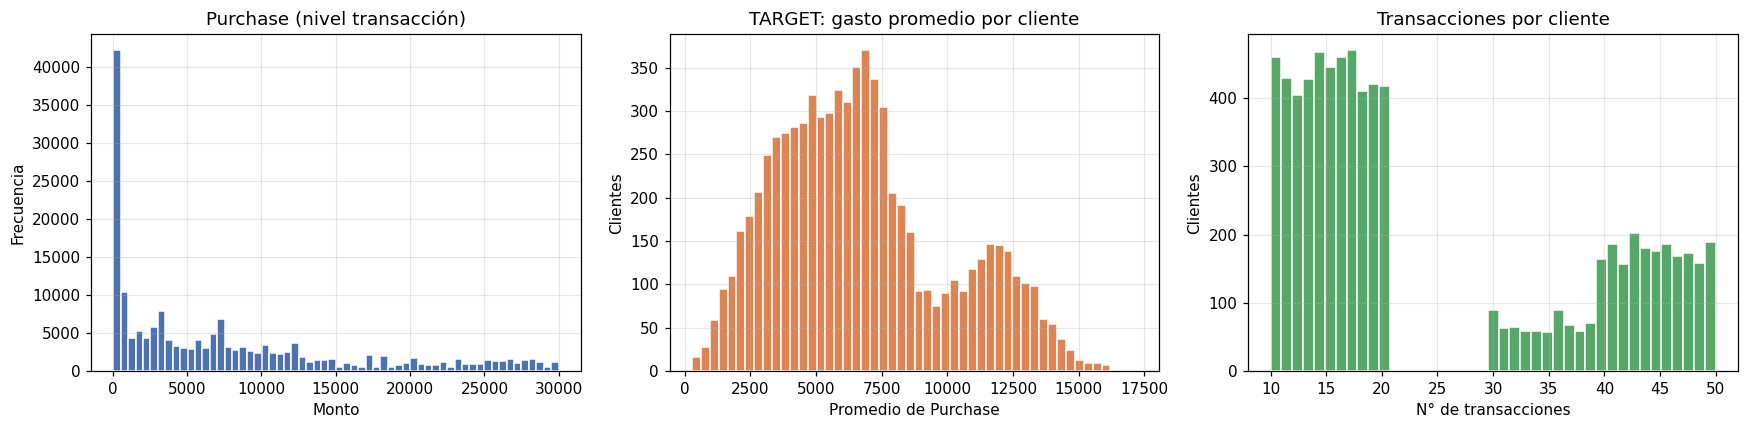

Purchase por transacción : media=7,852  sd=8,321
Gasto promedio por cliente: media=6,750  sd=3,298  rango=[275, 17,231]


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df.Purchase, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Purchase (nivel transacción)')
axes[0].set_xlabel('Monto'); axes[0].set_ylabel('Frecuencia')

gasto_medio = df.groupby('User_ID').Purchase.mean()
axes[1].hist(gasto_medio, bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('TARGET: gasto promedio por cliente')
axes[1].set_xlabel('Promedio de Purchase'); axes[1].set_ylabel('Clientes')

axes[2].hist(tx_por_cliente, bins=41, color='#55A868', edgecolor='white')
axes[2].set_title('Transacciones por cliente')
axes[2].set_xlabel('N° de transacciones'); axes[2].set_ylabel('Clientes')

plt.tight_layout(); plt.show()

print(f'Purchase por transacción : media={df.Purchase.mean():,.0f}  sd={df.Purchase.std():,.0f}')
print(f'Gasto promedio por cliente: media={gasto_medio.mean():,.0f}  sd={gasto_medio.std():,.0f}  '
      f'rango=[{gasto_medio.min():,.0f}, {gasto_medio.max():,.0f}]')

La distribución de `Purchase` a nivel transacción es fuertemente **multimodal** (se ven al menos tres grupos de precios), pero al promediar por cliente el target se vuelve razonablemente simétrico y unimodal, con media ≈ 6.750 y desvío ≈ 3.300. Esto es una buena noticia para la red: no hace falta transformar el target con logaritmo, alcanza con estandarizarlo.

Una descomposición de la varianza que conviene mirar antes de modelar:

In [19]:
var_entre = gasto_medio.var()                                   # varianza ENTRE clientes  (señal)
var_intra = df.groupby('User_ID').Purchase.var().mean()         # varianza DENTRO de cada cliente (ruido)

print(f'Varianza ENTRE clientes  (lo que el modelo puede explicar): {var_entre:,.0f}')
print(f'Varianza INTRA cliente   (dispersión de sus propias compras): {var_intra:,.0f}')
print(f'Ratio intra/entre: {var_intra / var_entre:.1f}x')
print(f'\nCoeficiente de correlación intraclase (ICC) = {var_entre / (var_entre + var_intra):.3f}')

Varianza ENTRE clientes  (lo que el modelo puede explicar): 10,876,089
Varianza INTRA cliente   (dispersión de sus propias compras): 54,288,124
Ratio intra/entre: 5.0x

Coeficiente de correlación intraclase (ICC) = 0.167


La varianza **dentro** de cada cliente es 5 veces mayor que la varianza **entre** clientes. Traducido al negocio: un mismo cliente compra cosas de precios muy distintos, y las diferencias de gasto promedio entre clientes son comparativamente chicas. Esto tiene una consecuencia directa y cuantificable sobre el objetivo declarado: si quisiéramos estimar el promedio de un cliente usando sólo $K$ compras suyas, el error de esa estimación tendría varianza $\sigma^2_{\text{intra}}/K$, que para $K=5$ es del mismo orden que toda la señal disponible. Volvemos sobre esto al final.

### Hallazgo estructural: `Purchase` es el **precio del producto**, no un monto negociado

Antes de decidir qué features construir, verificamos qué es realmente la columna `Purchase`.

Desvío de Purchase DENTRO de cada Product_ID: max = 0.000000
-> cada Product_ID tiene un precio ÚNICO y fijo en todo el dataset.

Categorías distintas por Product_ID: max = 1
Subcategoría_1 distinta por Product_ID: max = 1
-> Product_Category y Product_Subcategory_* son ATRIBUTOS DEL PRODUCTO, no del cliente ni de la compra.



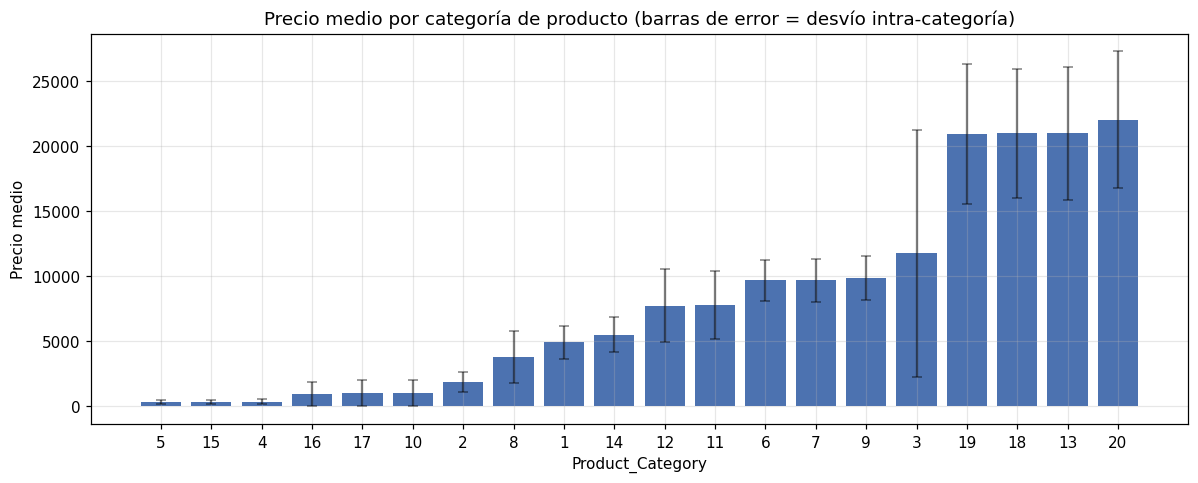

,mean,std,count
Product_Category,,,
5,325.0,166.0,8889
15,326.0,158.0,6406
4,338.0,169.0,7764
16,916.0,934.0,11783
17,990.0,1010.0,13711
10,995.0,1011.0,14068
2,1835.0,781.0,4032
8,3758.0,2024.0,8796
1,4897.0,1255.0,6261


In [20]:
sd_por_producto = df.groupby('Product_ID').Purchase.std()
print(f'Desvío de Purchase DENTRO de cada Product_ID: max = {sd_por_producto.max():.6f}')
print(f'-> cada Product_ID tiene un precio ÚNICO y fijo en todo el dataset.\n')

print(f'Categorías distintas por Product_ID: max = {df.groupby("Product_ID").Product_Category.nunique().max()}')
print(f'Subcategoría_1 distinta por Product_ID: max = {df.groupby("Product_ID").Product_Subcategory_1.nunique().max()}')
print('-> Product_Category y Product_Subcategory_* son ATRIBUTOS DEL PRODUCTO, no del cliente ni de la compra.\n')

precio_cat = df.groupby('Product_Category').Purchase.agg(['mean', 'std', 'count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(precio_cat.index.astype(str), precio_cat['mean'], yerr=precio_cat['std'],
       color='#4C72B0', capsize=3, error_kw=dict(alpha=0.5))
ax.set_xlabel('Product_Category'); ax.set_ylabel('Precio medio')
ax.set_title('Precio medio por categoría de producto (barras de error = desvío intra-categoría)')
plt.tight_layout(); plt.show()
display(precio_cat.round(0))

Esto reencuadra completamente el problema. Como el precio está determinado por el producto, el gasto promedio de un cliente **es el precio promedio de la canasta que elige**:

$$\text{gasto promedio}_u \;=\; \frac{1}{n_u}\sum_{i \in u} \text{precio}(\text{producto}_i).$$

Por lo tanto **no hay nada que predecir sobre "cuánto paga" un cliente: hay que predecir *qué compra***. El gráfico de precios por categoría muestra además que las 20 categorías se agrupan en tres escalones muy separados: baratas (categorías 4, 5, 15, con precio medio ≈ 330), intermedias (≈ 900 a 10.000) y caras (categorías 13, 18, 19, 20, con precio medio ≈ 21.000). Un cliente que compra sistemáticamente en el escalón caro tiene un gasto promedio 60 veces mayor que uno del escalón barato.

La consecuencia para el feature engineering es clara: **la composición por categoría de la canasta del cliente es la variable predictiva central**, y la demografía sólo puede ayudar en la medida en que explique esa composición.

Product_Subcategory_1: % nulos =  22.9%  | ¿la nulidad es constante dentro de cada Product_ID? SÍ
Product_Subcategory_2: % nulos =  57.6%  | ¿la nulidad es constante dentro de cada Product_ID? SÍ


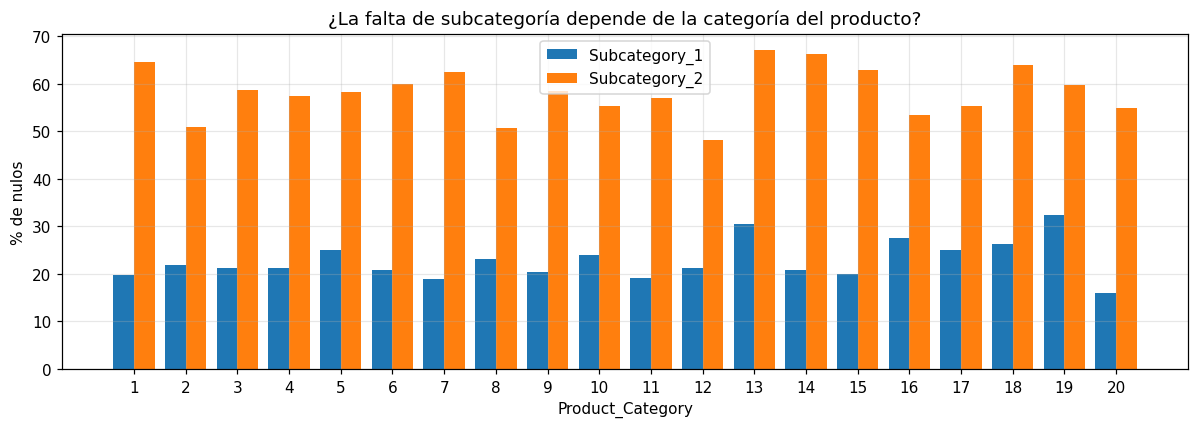


Dispersión del % de nulos de Subcat_1 entre categorías: 16.0% a 32.3%
Dispersión del % de nulos de Subcat_2 entre categorías: 48.2% a 67.2%


In [21]:
# --- Estructura de los valores faltantes ---
for col in ['Product_Subcategory_1', 'Product_Subcategory_2']:
    por_producto = df.groupby('Product_ID')[col].apply(lambda s: s.isna().nunique()).max()
    print(f'{col}: % nulos = {df[col].isna().mean()*100:5.1f}%  | '
          f'¿la nulidad es constante dentro de cada Product_ID? {"SÍ" if por_producto == 1 else "NO"}')

nulidad_cat = pd.DataFrame({
    'Subcat_1 % nulo': df.assign(n=df.Product_Subcategory_1.isna()).groupby('Product_Category').n.mean() * 100,
    'Subcat_2 % nulo': df.assign(n=df.Product_Subcategory_2.isna()).groupby('Product_Category').n.mean() * 100,
}).round(1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(nulidad_cat.index - 0.2, nulidad_cat['Subcat_1 % nulo'], width=0.4, label='Subcategory_1')
ax.bar(nulidad_cat.index + 0.2, nulidad_cat['Subcat_2 % nulo'], width=0.4, label='Subcategory_2')
ax.set_xlabel('Product_Category'); ax.set_ylabel('% de nulos')
ax.set_title('¿La falta de subcategoría depende de la categoría del producto?')
ax.set_xticks(nulidad_cat.index); ax.legend()
plt.tight_layout(); plt.show()

print(f'\nDispersión del % de nulos de Subcat_1 entre categorías: '
      f'{nulidad_cat["Subcat_1 % nulo"].min():.1f}% a {nulidad_cat["Subcat_1 % nulo"].max():.1f}%')
print(f'Dispersión del % de nulos de Subcat_2 entre categorías: '
      f'{nulidad_cat["Subcat_2 % nulo"].min():.1f}% a {nulidad_cat["Subcat_2 % nulo"].max():.1f}%')

### Decisiones sobre nulos

Sólo dos columnas tienen faltantes, y en ambas la nulidad es **constante dentro de cada `Product_ID`**: no es que falte el dato de una compra puntual, sino que hay productos que directamente no están catalogados en ese nivel de detalle. Eso descarta de entrada cualquier imputación por media/moda a nivel transacción, que introduciría información inventada.

- **`Product_Subcategory_2` (57,6% nulos) → se elimina.** Más de la mitad de las filas no la tienen y, como el gráfico muestra, la nulidad se reparte de forma bastante pareja entre categorías (48% a 67%), o sea que tampoco es una nulidad *informativa* que valga la pena codificar como categoría aparte. Con 16 niveles y 42% de cobertura, cualquier agregado por cliente quedaría armado sobre muy pocas observaciones. No tiene salvación: se dropea.
- **`Product_Subcategory_1` (22,9% nulos) → se conserva, con el nulo como categoría propia.** La cobertura es del 77% y la nulidad tampoco depende de la categoría (16% a 32%), así que la tratamos como una etiqueta más (`"sin_subcategoria"`) en vez de descartar el 23% de los datos. Más abajo medimos empíricamente si aporta algo por encima de `Product_Category`; si no aporta, la descartamos por parsimonia y no por un criterio a priori.

### Decisiones sobre qué columnas se usan

| Columna | Decisión | Motivo |
|---|---|---|
| `User_ID` | **clave de agrupamiento**, no feature | Es un identificador arbitrario. Usarlo como número sería inventar un orden; usarlo con one-hot daría 7.432 columnas y memorización pura. Sí lo usamos para agrupar y para particionar. |
| `Product_ID` | **se elimina como feature**, se usa para derivar | 2.455 niveles, y como cada producto tiene precio único, codificarlo permitiría reconstruir el target casi exactamente. Lo usamos sólo para contar productos distintos (diversidad). |
| `Age`, `Gender`, `Marital_Status`, `City_Category`, `Stay_In_Current_City_Years` | **se conservan** | Son atributos del cliente, constantes dentro de cada `User_ID` (lo verificamos abajo). Son la única información disponible para un cliente sobre el que todavía no sabemos nada. |
| `Product_Category` | **se conserva, agregada a nivel cliente** | Es el driver principal del gasto, según lo que acabamos de ver. |
| `Product_Subcategory_1` | **candidata**, se decide empíricamente | Ver ablación más abajo. |
| `Product_Subcategory_2` | **se elimina** | 57,6% de nulos. |
| `Purchase` | **es el target**, nunca feature | Cualquier agregado suyo sería leakage directo. |

In [22]:
# Verificación: los atributos demográficos son constantes dentro de cada cliente
DEMO = ['Age', 'Gender', 'Marital_Status', 'City_Category', 'Stay_In_Current_City_Years']
inconsistentes = df.groupby('User_ID')[DEMO].nunique().gt(1).sum()
print('Clientes con demografía inconsistente (debería ser 0 en todas):')
display(inconsistentes.to_frame('n_clientes_inconsistentes'))

Clientes con demografía inconsistente (debería ser 0 en todas):


,n_clientes_inconsistentes
Age,0
Gender,0
Marital_Status,0
City_Category,0
Stay_In_Current_City_Years,0


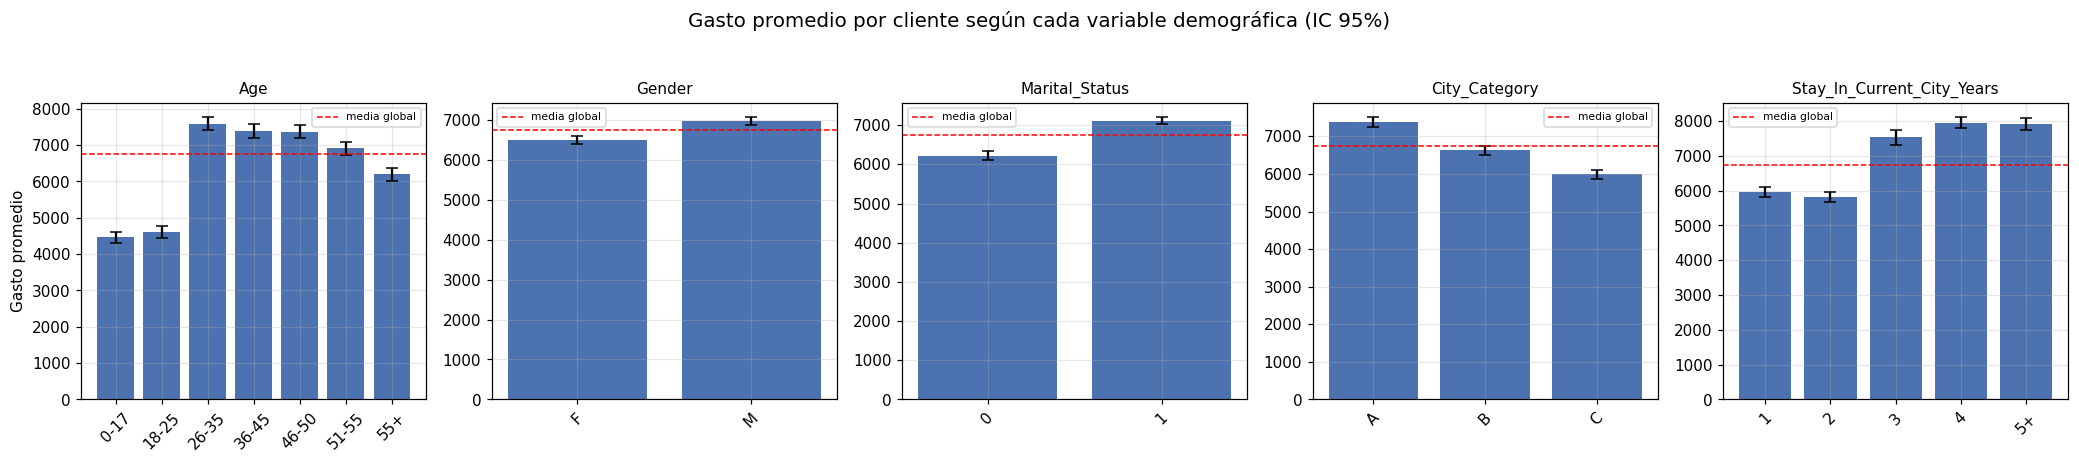

Age                            {'0-17': 4463.0, '18-25': 4616.0, '26-35': 7594.0, '36-45': 7385.0, '46-50': 7370.0, '51-55': 6913.0, '55+': 6199.0}
Gender                         {'F': 6503.0, 'M': 6973.0}
Marital_Status                 {0: 6215.0, 1: 7116.0}
City_Category                  {'A': 7390.0, 'B': 6633.0, 'C': 5986.0}
Stay_In_Current_City_Years     {'1': 5963.0, '2': 5822.0, '3': 7530.0, '4': 7956.0, '5+': 7917.0}


In [23]:
# --- Relación de cada variable demográfica con el TARGET, a nivel cliente ---
clientes_demo = df.groupby('User_ID')[DEMO].first()
clientes_demo['gasto_promedio'] = gasto_medio

orden = {'Age': ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+'],
         'Gender': ['F', 'M'],
         'Marital_Status': [0, 1],
         'City_Category': ['A', 'B', 'C'],
         'Stay_In_Current_City_Years': ['1', '2', '3', '4', '5+']}

fig, axes = plt.subplots(1, 5, figsize=(19, 4))
for ax, col in zip(axes, DEMO):
    g = clientes_demo.groupby(col).gasto_promedio.agg(['mean', 'sem', 'count']).reindex(orden[col])
    ax.bar([str(i) for i in g.index], g['mean'], yerr=1.96 * g['sem'], color='#4C72B0', capsize=4)
    ax.axhline(clientes_demo.gasto_promedio.mean(), color='red', ls='--', lw=1, label='media global')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Gasto promedio' if col == 'Age' else '')
    ax.legend(fontsize=7)
fig.suptitle('Gasto promedio por cliente según cada variable demográfica (IC 95%)', y=1.04, fontsize=13)
plt.tight_layout(); plt.show()

for col in DEMO:
    g = clientes_demo.groupby(col).gasto_promedio.mean().reindex(orden[col]).round(0)
    print(f'{col:30s}', g.to_dict())

### Decisiones de encoding, una por una

El criterio general que aplicamos: **el encoding debe reflejar la geometría que la variable tiene respecto del target, no sólo la que tiene "en el papel"**. Una variable puede tener un orden natural en sus etiquetas y sin embargo no tener un efecto monótono sobre el target; en ese caso el ordinal encoding le impone a la red una restricción falsa.

**`Gender` → label / binary encoding (F=0, M=1).**
Es nominal con 2 niveles. Con dos categorías, label encoding y one-hot con `drop_first` producen exactamente la misma columna, así que el debate no existe: una sola columna binaria. El efecto es chico (M ≈ 6.973 vs F ≈ 6.503, ~7% de diferencia) pero consistente.

**`Marital_Status` → sin encoding, ya viene como 0/1.**
Idem: una columna binaria. Casados ≈ 7.116 vs solteros ≈ 6.215.

**`City_Category` → ordinal / mapping encoding (C=1, B=2, A=3).**
Es el único caso donde usamos ordinal, y lo hacemos con doble justificación. Primero, **por contexto de negocio**: el enunciado define explícitamente A = barrio de clase alta, B = clase media, C = clase media-baja, o sea que hay un orden socioeconómico real. Segundo, **porque el dato lo confirma**: el gasto promedio es monótono en ese orden (A = 7.390 > B = 6.633 > C = 5.986) y los intervalos de confianza no se solapan. Cuando el orden conceptual y el orden empírico coinciden, el ordinal encoding es preferible al one-hot porque usa una columna en lugar de tres y le entrega a la red la información del orden en vez de obligarla a redescubrirla.

**`Age` → one-hot encoding, a pesar de ser ordinal en apariencia.**
Este es el caso más interesante y donde el criterio "mirar la geometría" cambia la decisión. Los rangos etarios tienen un orden obvio, pero su efecto sobre el gasto **no es monótono**: es una U invertida. Los dos grupos más jóvenes gastan muy poco (0-17 ≈ 4.464, 18-25 ≈ 4.616), hay un salto abrupto en 26-35 ≈ 7.594, y a partir de ahí desciende suavemente hasta 55+ ≈ 6.199. Si codificáramos `Age` como 1..7, estaríamos forzando a la red a representar esa forma con una única dirección en el espacio de entrada; con una capa oculta suficientemente ancha podría aproximarla, pero le estaríamos gastando capacidad en algo que el encoding puede resolver gratis. Con one-hot, cada rango recibe su propio peso y la U invertida se aprende directamente. **Conclusión: orden en las etiquetas ≠ efecto monótono; lo que manda para elegir el encoding es lo segundo.**

**`Stay_In_Current_City_Years` → one-hot encoding, por el mismo motivo y por un motivo extra.**
El efecto tampoco es monótono ni suave: hay dos mesetas separadas por un escalón entre el año 2 y el 3 (1 → 5.963 y 2 → 5.822, contra 3 → 7.530, 4 → 7.956 y 5+ → 7.917). No es una tendencia gradual "cuanto más antiguo, más gasta", es un corte. Además el nivel `'5+'` está **censurado**: agrupa 5, 8 o 15 años en la misma etiqueta, así que asignarle el número 5 sería una afirmación falsa sobre la distancia entre categorías. Con one-hot evitamos ambos problemas. (Nota de negocio: el enunciado define esta variable como los años que el cliente lleva comprando en la tienda, así que el escalón sugiere que los clientes que sobreviven más de 2 años son un segmento distinto, probablemente más fidelizado.)

**`Product_Category` → *frequency encoding* a nivel cliente (proporciones), que es lo que corresponde al cambiar la unidad de análisis.**
A nivel transacción es una nominal de 20 niveles y el encoding natural sería one-hot. Pero nuestra unidad es el cliente, y un cliente tiene muchas transacciones de muchas categorías: lo que necesitamos no es "qué categoría compró" sino "**cómo reparte sus compras entre las 20 categorías**". Por eso la agregamos como un vector de 20 proporciones, $p_{u,c} = n_{u,c}/n_u$, que es exactamente la "tendencia de gustos" que pide el enunciado.

**Sobre el leakage de estas proporciones.** El enunciado advierte específicamente sobre usar proporciones como columnas nuevas, así que explicitamos por qué éstas son legítimas: se calculan **contando transacciones, sin mirar ni una sola vez la columna `Purchase`**. La versión leaky sería la proporción del *gasto* por categoría, $\sum_{i\in c}\text{Purchase}_i / \sum_{i\in u}\text{Purchase}_i$, que sí usa el target y con la que se reconstruiría el promedio de forma casi exacta. Esa no la usamos. Tampoco usamos suma, máximo, mínimo ni desvío de `Purchase`.

Con todo, hay que ser honestos sobre lo que sí ocurre: como el precio está determinado por el producto, se cumple aproximadamente
$$\text{gasto promedio}_u \approx \sum_{c} p_{u,c}\cdot \overline{\text{precio}}_c ,$$
o sea que las proporciones **son** una parametrización casi suficiente del target. No es leakage —no usamos el target para construirlas— pero sí explica por qué el $R^2$ va a resultar muy alto, y por qué no habría que leer ese número como "el modelo entiende a los clientes". Lo discutimos en las conclusiones.

In [24]:
# ============================================================
#  Construcción de la tabla a nivel CLIENTE (feature engineering)
# ============================================================
CATEGORIAS = sorted(df.Product_Category.unique())

def construir_tabla_clientes(transacciones, incluir_subcat1=False):
    """Convierte una tabla de transacciones en una tabla de clientes (1 fila por cliente).

    NINGUNA feature usa la columna Purchase: todas se construyen contando qué compró el
    cliente, no cuánto pagó.
    """
    g = transacciones.groupby('User_ID')

    # --- Bloque 1: demografía (constante dentro del cliente) ---
    demografia = g[DEMO].first()

    # --- Bloque 2: mezcla de categorías (frequency encoding por conteo) ---
    mezcla = (pd.crosstab(transacciones.User_ID, transacciones.Product_Category, normalize='index')
                .reindex(columns=CATEGORIAS, fill_value=0.0)
                .add_prefix('prop_cat_'))

    # --- Bloque 3: intensidad y diversidad de la canasta ---
    n_tx = g.size()
    comportamiento = pd.DataFrame({
        'n_transacciones': n_tx,
        'n_categorias_distintas': g.Product_Category.nunique(),
        'n_productos_distintos': g.Product_ID.nunique(),
        # Índice de Herfindahl: 1 = compra siempre en la misma categoría, ~0 = muy diversificado
        'concentracion_hhi': (mezcla.values ** 2).sum(axis=1),
    }, index=mezcla.index)
    comportamiento['tasa_recompra'] = 1 - comportamiento.n_productos_distintos / comportamiento.n_transacciones
    comportamiento['categorias_por_compra'] = comportamiento.n_categorias_distintas / comportamiento.n_transacciones

    tabla = demografia.join(mezcla).join(comportamiento)

    # --- Bloque 4 (opcional): mezcla de subcategoría_1, con el nulo como categoría propia ---
    if incluir_subcat1:
        tmp = transacciones.assign(_s1=transacciones.Product_Subcategory_1.fillna(-1).astype(int))
        sub = (pd.crosstab(tmp.User_ID, tmp._s1, normalize='index').add_prefix('prop_sub1_'))
        tabla = tabla.join(sub.reindex(index=tabla.index, fill_value=0.0))

    return tabla


def aplicar_encodings(tabla):
    """Aplica los encodings decididos en el análisis de arriba."""
    t = tabla.copy()
    t['Gender'] = (t.Gender == 'M').astype(int)                                   # label/binary
    t['City_nivel'] = t.City_Category.map({'C': 1, 'B': 2, 'A': 3})               # ordinal/mapping
    t = t.drop(columns=['City_Category'])
    t = pd.get_dummies(t, columns=['Age', 'Stay_In_Current_City_Years'],          # one-hot
                       prefix=['edad', 'antig'], drop_first=True)
    return t.astype(np.float32)


tabla_cruda = construir_tabla_clientes(df)
X_clientes = aplicar_encodings(tabla_cruda)
y_clientes = gasto_medio.reindex(X_clientes.index).rename('gasto_promedio')

print(f'Tabla de clientes: {X_clientes.shape[0]:,} filas x {X_clientes.shape[1]} features')
print(f'\nFeatures: {list(X_clientes.columns)}')
display(X_clientes.head())

Tabla de clientes: 7,432 filas x 39 features

Features: ['Gender', 'Marital_Status', 'prop_cat_1', 'prop_cat_2', 'prop_cat_3', 'prop_cat_4', 'prop_cat_5', 'prop_cat_6', 'prop_cat_7', 'prop_cat_8', 'prop_cat_9', 'prop_cat_10', 'prop_cat_11', 'prop_cat_12', 'prop_cat_13', 'prop_cat_14', 'prop_cat_15', 'prop_cat_16', 'prop_cat_17', 'prop_cat_18', 'prop_cat_19', 'prop_cat_20', 'n_transacciones', 'n_categorias_distintas', 'n_productos_distintos', 'concentracion_hhi', 'tasa_recompra', 'categorias_por_compra', 'City_nivel', 'edad_18-25', 'edad_26-35', 'edad_36-45', 'edad_46-50', 'edad_51-55', 'edad_55+', 'antig_2', 'antig_3', 'antig_4', 'antig_5+']


,Gender,Marital_Status,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,...,edad_18-25,edad_26-35,edad_36-45,edad_46-50,edad_51-55,edad_55+,antig_2,antig_3,antig_4,antig_5+
User_ID,,,,,,,,,,,,,,,,,,,,,
1000035,1.0,0.0,0.000000,0.00000,0.000000,0.000000,0.153846,0.000000,0.076923,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000044,1.0,1.0,0.023256,0.00000,0.116279,0.023256,0.000000,0.000000,0.116279,0.069767,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1000070,1.0,1.0,0.047619,0.02381,0.023810,0.023810,0.023810,0.023810,0.119048,0.047619,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1000087,0.0,1.0,0.048780,0.02439,0.024390,0.048780,0.024390,0.000000,0.048780,0.073171,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1000115,0.0,1.0,0.000000,0.00000,0.176471,0.176471,0.000000,0.117647,0.058824,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
# --- Chequeo explícito anti-leakage ---
print('Chequeo 1 - ninguna feature se llama ni deriva de Purchase:')
print('   columnas con "purchase" en el nombre:',
      [c for c in X_clientes.columns if 'purchase' in c.lower()], '-> OK\n')

print('Chequeo 2 - correlación de cada feature con el target (las proporciones de categoría')
print('   deben correlacionar fuerte, pero por composición de canasta, no por leakage):')
corr = X_clientes.apply(lambda c: np.corrcoef(c, y_clientes)[0, 1]).sort_values(key=abs, ascending=False)
display(corr.head(12).to_frame('corr con gasto promedio').round(3))

print('Chequeo 3 - ninguna feature reproduce el target de forma exacta:')
print(f'   correlación máxima en valor absoluto = {corr.abs().max():.3f}  (si fuera ~1.0 habría un problema)')

Chequeo 1 - ninguna feature se llama ni deriva de Purchase:
   columnas con "purchase" en el nombre: [] -> OK

Chequeo 2 - correlación de cada feature con el target (las proporciones de categoría
   deben correlacionar fuerte, pero por composición de canasta, no por leakage):


,corr con gasto promedio
prop_cat_20,0.611
n_transacciones,0.600
n_categorias_distintas,0.596
n_productos_distintos,0.594
prop_cat_18,0.590
prop_cat_19,0.572
prop_cat_13,0.567
concentracion_hhi,-0.484
prop_cat_3,0.472
prop_cat_5,-0.470


Chequeo 3 - ninguna feature reproduce el target de forma exacta:
   correlación máxima en valor absoluto = 0.611  (si fuera ~1.0 habría un problema)


In [26]:
# --- Ablación: ¿cuánto aporta cada bloque de features? (Ridge como sonda rápida) ---
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score

rng_abl = np.random.default_rng(42)
_u = X_clientes.index.values.copy(); rng_abl.shuffle(_u)
_tr, _va = _u[:int(0.8 * len(_u))], _u[int(0.8 * len(_u)):]

cols_demo = [c for c in X_clientes.columns if c.startswith(('edad', 'antig')) or
             c in ('Gender', 'Marital_Status', 'City_nivel')]
cols_mezcla = [c for c in X_clientes.columns if c.startswith('prop_cat_')]
cols_comport = ['n_transacciones', 'n_categorias_distintas', 'n_productos_distintos',
                'concentracion_hhi', 'tasa_recompra', 'categorias_por_compra']

X_con_sub1 = aplicar_encodings(construir_tabla_clientes(df, incluir_subcat1=True))
cols_sub1 = [c for c in X_con_sub1.columns if c.startswith('prop_sub1_')]

bloques = {
    'Sólo demografía':                         (X_clientes, cols_demo),
    '+ comportamiento (diversidad/recompra)':  (X_clientes, cols_demo + cols_comport),
    '+ mezcla de categorías':                  (X_clientes, cols_demo + cols_comport + cols_mezcla),
    '+ mezcla de subcategoría_1':              (X_con_sub1, cols_demo + cols_comport + cols_mezcla + cols_sub1),
}

filas = []
for nombre, (Xb, cols) in bloques.items():
    Xs = Xb[cols]
    m = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(Xs.loc[_tr], y_clientes.loc[_tr])
    filas.append({'Bloque de features': nombre, 'N° features': len(cols),
                  'R2 validación (Ridge)': round(r2_score(y_clientes.loc[_va], m.predict(Xs.loc[_va])), 4)})

display(pd.DataFrame(filas).style.hide(axis='index')
        .set_caption('Ablación de bloques de features (sonda con regresión Ridge)'))

Bloque de features,N° features,R2 validación (Ridge)
Sólo demografía,13,0.297100
+ comportamiento (diversidad/recompra),19,0.439700
+ mezcla de categorías,39,0.938700
+ mezcla de subcategoría_1,73,0.941200


**Lectura de la ablación.**

- La **demografía sola** llega a $R^2\approx0.30$. Es decir: sabiendo únicamente edad, género, estado civil, zona y antigüedad de un cliente, se explica menos de un tercio de la variabilidad de su gasto. Es poco, pero no es nada, y es la única información disponible para un cliente con cero compras.
- Agregar **comportamiento** (diversidad, recompra, cantidad de transacciones) sube a $\approx0.44$. Aporta, y es información barata de obtener.
- Agregar la **mezcla de categorías** lleva el salto grande, a $\approx0.94$. Consistente con lo que anticipamos: el gasto promedio es esencialmente el precio promedio de la canasta.
- Agregar la **mezcla de subcategoría_1** suma apenas $\approx0.003$ a cambio de 34 columnas nuevas, muchas de ellas casi vacías. **La descartamos por parsimonia**: más parámetros, más riesgo de sobreajuste y ninguna ganancia real. Esta es la decisión empírica que anunciamos al hablar de los nulos: `Product_Subcategory_1` no se descarta por tener nulos, se descarta porque, medida contra `Product_Category`, es redundante.

Nos quedamos entonces con **39 features**: 13 de demografía codificada (`Gender`, `Marital_Status`, `City_nivel`, 6 dummies de edad y 4 de antigüedad), 20 de mezcla de categorías y 6 de comportamiento.

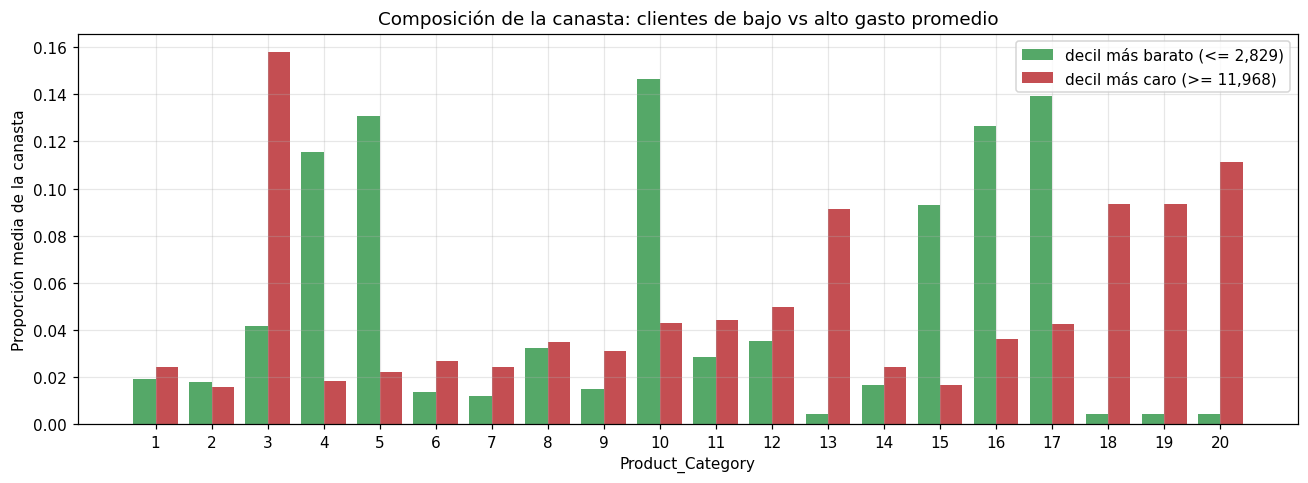

In [27]:
# --- Un último vistazo: perfil de canasta de los clientes más baratos vs los más caros ---
q_bajo = y_clientes.quantile(0.10)
q_alto = y_clientes.quantile(0.90)
grupo_bajo = X_clientes.loc[y_clientes <= q_bajo, cols_mezcla].mean()
grupo_alto = X_clientes.loc[y_clientes >= q_alto, cols_mezcla].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
idx = np.arange(len(CATEGORIAS))
ax.bar(idx - 0.2, grupo_bajo.values, width=0.4, label=f'decil más barato (<= {q_bajo:,.0f})', color='#55A868')
ax.bar(idx + 0.2, grupo_alto.values, width=0.4, label=f'decil más caro (>= {q_alto:,.0f})', color='#C44E52')
ax.set_xticks(idx); ax.set_xticklabels(CATEGORIAS)
ax.set_xlabel('Product_Category'); ax.set_ylabel('Proporción media de la canasta')
ax.set_title('Composición de la canasta: clientes de bajo vs alto gasto promedio')
ax.legend(); plt.tight_layout(); plt.show()

### Conclusiones preliminares del EDA (2a)

1. **El dataset es de transacciones pero el problema es de clientes.** 182.721 filas colapsan en 7.432 unidades de análisis. Todo lo demás (partición, features, métricas) se desprende de haber fijado esa unidad correctamente al principio.

2. **`Purchase` es el precio del producto.** Cada `Product_ID` tiene un precio único e invariable. Esto convierte el problema de "predecir cuánto gasta un cliente" en "predecir qué compra un cliente", y explica por qué la composición de la canasta domina sobre la demografía.

3. **Las categorías se organizan en tres escalones de precio muy separados** (≈330, ≈900-10.000 y ≈21.000). La diferencia de gasto promedio entre clientes está determinada casi enteramente por en qué escalón se mueven, no por variaciones finas de precio.

4. **La demografía tiene efectos reales pero modestos, y varios de ellos no son monótonos.** `Age` describe una U invertida (los menores de 25 gastan ~40% menos que el pico de 26-35) y `Stay_In_Current_City_Years` muestra un escalón entre el año 2 y el 3, no una tendencia gradual. Esto es lo que justifica el one-hot en ambas y el ordinal sólo en `City_Category`, donde el orden de negocio y el orden empírico coinciden.

5. **`Product_Subcategory_2` no tiene salvación** (57,6% de nulos, nulidad no informativa) y `Product_Subcategory_1`, aunque recuperable, resulta **redundante** frente a `Product_Category`: aporta +0,003 de $R^2$ con 34 columnas extra. Ambas quedan afuera, cada una por su motivo.

6. **La varianza dentro de cada cliente quintuplica la varianza entre clientes.** Este es el número que más condiciona el objetivo de negocio: cuanto menos historial tengamos de un cliente, más ruidosa es cualquier estimación de su gasto promedio. Con el historial completo (10 a 50 compras) el problema es fácil; con 3 a 5 compras no lo es. Lo medimos explícitamente después de entrenar el modelo.

7. **El leakage está controlado por construcción**: ninguna feature toca `Purchase`, la partición es por cliente y las proporciones se calculan por conteo de transacciones y no por monto gastado.

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

#### Partición de los datos

Usamos **tres** conjuntos y no dos, aunque la consigna sólo pida train y validation:

- **train (70%)** para ajustar los pesos,
- **validation (15%)** para elegir hiperparámetros y decidir cuándo cortar el entrenamiento,
- **test (15%)** que no se toca hasta el final.

El motivo es que vamos a usar validación para el *early stopping* y para comparar activaciones, optimizadores y learning rates. Una vez que se usa un conjunto para tomar decisiones, el error medido sobre él deja de ser un estimador insesgado: queda contaminado por el proceso de selección. Reportar el $R^2$ de validación como si fuera el desempeño esperado en producción sería optimista. El conjunto de test nos da la medida honesta. Reportamos los tres.

La partición es **por `User_ID`**, que es la unidad de análisis: cada cliente aparece en un solo conjunto.

In [28]:
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Partición por cliente: 70 / 15 / 15 ---
usuarios = X_clientes.index.values.copy()
np.random.default_rng(SEED).shuffle(usuarios)
n_tr = int(0.70 * len(usuarios))
n_va = int(0.15 * len(usuarios))
u_train = usuarios[:n_tr]
u_val   = usuarios[n_tr:n_tr + n_va]
u_test  = usuarios[n_tr + n_va:]

print(f'train: {len(u_train):,} clientes | validation: {len(u_val):,} | test: {len(u_test):,}')
print(f'Sin solapamiento entre conjuntos: '
      f'{len(set(u_train) & set(u_val)) == 0 and len(set(u_val) & set(u_test)) == 0}')

# --- Estandarización: los estadísticos se calculan SÓLO con train ---
mu_X = X_clientes.loc[u_train].mean()
sd_X = X_clientes.loc[u_train].std().replace(0, 1.0)
mu_y = float(y_clientes.loc[u_train].mean())
sd_y = float(y_clientes.loc[u_train].std())

def a_tensores(usuarios_, X=X_clientes, y=y_clientes):
    Xs = ((X.loc[usuarios_] - mu_X) / sd_X).values.astype(np.float32)
    ys = ((y.loc[usuarios_] - mu_y) / sd_y).values.astype(np.float32).reshape(-1, 1)
    return torch.tensor(Xs), torch.tensor(ys)

Xtr, ytr = a_tensores(u_train)
Xva, yva = a_tensores(u_val)
Xte, yte = a_tensores(u_test)
N_FEATURES = Xtr.shape[1]

print(f'\nTensores: X_train {tuple(Xtr.shape)}, X_val {tuple(Xva.shape)}, X_test {tuple(Xte.shape)}')
print(f'Target estandarizado con mu={mu_y:,.1f} y sd={sd_y:,.1f} (estadísticos de train)')

train: 5,202 clientes | validation: 1,114 | test: 1,116
Sin solapamiento entre conjuntos: True

Tensores: X_train (5202, 39), X_val (1114, 39), X_test (1116, 39)
Target estandarizado con mu=6,745.3 y sd=3,311.4 (estadísticos de train)


Estandarizamos también el **target**. No es imprescindible, pero con valores del orden de 7.000 el MSE inicial sería del orden de $10^7$ y los gradientes de la última capa arrancarían enormes, obligando a un learning rate muy chico. Trabajando en unidades de desvío estándar, el MSE inicial es $\approx 1$ y los valores por defecto de Adam funcionan directamente. Todas las métricas las reportamos **desestandarizadas**, en pesos, para que sean interpretables.

#### Función de costo y estrategia de regularización

La arquitectura la elegimos empíricamente más abajo; acá fijamos las dos decisiones que se justifican antes de correr nada.

**Función de costo: MSE.** La justificación no es que "es la que se usa para regresión", sino que se sigue de tres cosas:
1. El target es continuo y aproximadamente simétrico (lo vimos en el histograma), sin la cola pesada que haría preferible una pérdida robusta.
2. Minimizar MSE equivale a estimar la **media condicional** $E[y\mid x]$, que es exactamente lo que pide el negocio: el gasto *promedio*. Si usáramos MAE estaríamos estimando la mediana condicional, que responde otra pregunta.
3. La métrica de evaluación que fija la consigna es el $R^2$, y $R^2 = 1 - \text{MSE}/\text{Var}(y)$. Entrenar con MSE es entrenar directamente sobre la métrica de evaluación; usar otra pérdida introduciría un desalineamiento innecesario.

Consideramos Huber por si hubiera clientes atípicos, pero el target está acotado entre 275 y 17.231 sin outliers extremos, así que la robustez extra no compra nada y sí sesga hacia la mediana.

**Regularización.** Incluimos `Dropout` en las capas ocultas y `weight_decay` en el optimizador. Con sólo 5.202 clientes de entrenamiento el riesgo de sobreajuste es concreto: sin ninguna regularización la red llega a $R^2$ de entrenamiento de 0,98 contra 0,92 en validación. Calibramos la intensidad de ambos empíricamente más abajo.

Todas las comparaciones que siguen se corren con la **misma semilla y la misma partición**, cambiando una sola cosa por vez, y las decisiones se toman sobre el conjunto de validación.

In [29]:
class MLPGasto(nn.Module):
    """MLP para regresión del gasto promedio por cliente."""

    def __init__(self, n_entrada, capas=(128, 64, 32), activacion=nn.ELU, p_dropout=0.2):
        super().__init__()
        bloques = []
        dim = n_entrada
        for n_neuronas in capas:
            bloques += [nn.Linear(dim, n_neuronas), activacion()]
            if p_dropout > 0:
                bloques.append(nn.Dropout(p_dropout))
            dim = n_neuronas
        bloques.append(nn.Linear(dim, 1))       # salida lineal: es una regresión
        self.red = nn.Sequential(*bloques)

    def forward(self, x):
        return self.red(x)


def r2_en(modelo, X, y):
    modelo.eval()
    with torch.no_grad():
        pred = modelo(X)
    return r2_score(y.numpy(), pred.numpy())


def entrenar(capas=(128, 64, 32), activacion=nn.ELU, p_dropout=0.2,
             optimizador='adam', lr=1e-3, weight_decay=1e-4,
             epocas=200, batch_size=64, paciencia=None, seed=SEED, verbose=False):
    """Entrena un MLP y devuelve el historial por época.

    Si `paciencia` no es None se aplica early stopping sobre la loss de validación,
    restaurando los pesos de la mejor época.
    """
    torch.manual_seed(seed)
    modelo = MLPGasto(N_FEATURES, capas, activacion, p_dropout)

    opt = {
        'adam':    lambda p: torch.optim.Adam(p, lr=lr, weight_decay=weight_decay),
        'sgd':     lambda p: torch.optim.SGD(p, lr=lr, momentum=0.9, weight_decay=weight_decay),
        'rmsprop': lambda p: torch.optim.RMSprop(p, lr=lr, weight_decay=weight_decay),
    }[optimizador](modelo.parameters())

    criterio = nn.MSELoss()
    n = len(Xtr)
    hist = {'loss_train': [], 'loss_val': [], 'r2_train': [], 'r2_val': []}
    mejor_loss, mejor_epoca, mejores_pesos, sin_mejora = np.inf, 0, None, 0

    for ep in range(1, epocas + 1):
        # --- entrenamiento (mini-batch, igual que en la Pregunta 1) ---
        modelo.train()
        orden = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = orden[i:i + batch_size]
            opt.zero_grad()
            perdida = criterio(modelo(Xtr[idx]), ytr[idx])
            perdida.backward()
            opt.step()

        # --- evaluación (modelo en modo eval: dropout desactivado) ---
        modelo.eval()
        with torch.no_grad():
            p_tr, p_va = modelo(Xtr), modelo(Xva)
            l_tr = criterio(p_tr, ytr).item()
            l_va = criterio(p_va, yva).item()
        hist['loss_train'].append(l_tr)
        hist['loss_val'].append(l_va)
        hist['r2_train'].append(r2_score(ytr.numpy(), p_tr.numpy()))
        hist['r2_val'].append(r2_score(yva.numpy(), p_va.numpy()))

        # --- early stopping sobre la loss de validación ---
        if l_va < mejor_loss - 1e-6:
            mejor_loss, mejor_epoca, sin_mejora = l_va, ep, 0
            mejores_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if paciencia is not None and sin_mejora >= paciencia:
                if verbose:
                    print(f'   early stopping en la época {ep} (mejor: {mejor_epoca})')
                break

    if paciencia is not None and mejores_pesos is not None:
        modelo.load_state_dict(mejores_pesos)

    hist['mejor_epoca'] = mejor_epoca
    return modelo, hist

#### Elección de la función de activación

Los argumentos teóricos acotan el campo pero no deciden, así que combinamos ambas cosas.

*Lo que dice la teoría.* Descartamos de entrada `Sigmoid` y `Tanh` para las capas ocultas: ambas saturan y aplastan el gradiente exactamente como vimos en la Pregunta 1, y con tres capas ocultas ese efecto se compone y se multiplica hacia atrás. `ReLU` es el default razonable —no satura para entradas positivas, es barata y su gradiente es exactamente 1— pero tiene el problema de las neuronas muertas, y acá es un riesgo real: nuestras 20 proporciones de categoría son **muy esparsas** (la mediana de un cliente tiene ceros en la mayoría de las categorías), así que muchas unidades reciben entradas nulas o negativas de forma sistemática. `ELU` y `SiLU` son las candidatas naturales frente a ese problema porque mantienen gradiente no nulo del lado negativo.

*Lo que dice el experimento.* Entrenamos la misma arquitectura cambiando sólo la activación.

Activación,Mejor R2 val,Época del máximo,R2 val @ época 150,R2 train @ época 150,Brecha train-val
ELU,0.937800,71,0.933800,0.951000,0.017100
SiLU (Swish),0.937000,66,0.932500,0.952600,0.020200
ReLU,0.936100,16,0.921400,0.976900,0.055400
LeakyReLU,0.935700,19,0.926000,0.977100,0.051200
Tanh,0.934100,86,0.932300,0.956000,0.023700


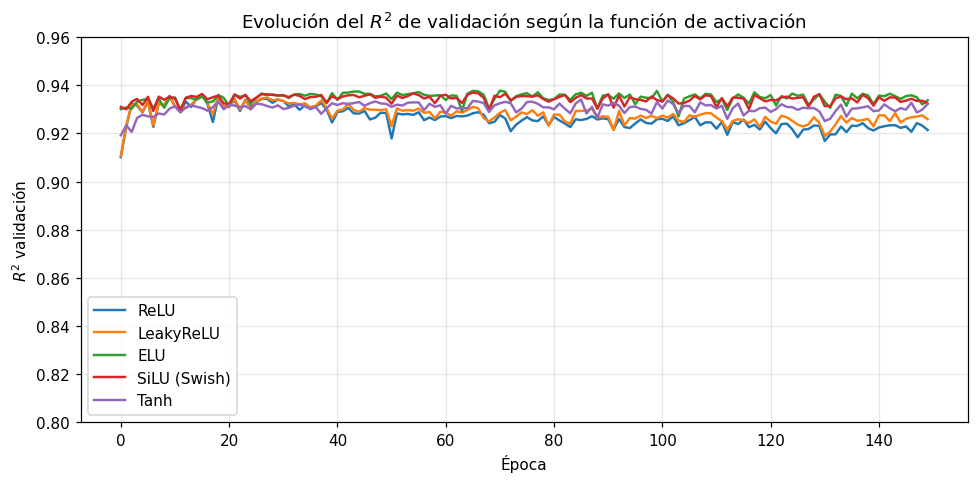

In [30]:
activaciones = {'ReLU': nn.ReLU, 'LeakyReLU': nn.LeakyReLU, 'ELU': nn.ELU,
                'SiLU (Swish)': nn.SiLU, 'Tanh': nn.Tanh}

filas = []
hist_act = {}
for nombre, act in activaciones.items():
    _, h = entrenar(activacion=act, epocas=150)
    hist_act[nombre] = h
    k = int(np.argmax(h['r2_val']))
    filas.append({'Activación': nombre,
                  'Mejor R2 val': round(h['r2_val'][k], 4),
                  'Época del máximo': k + 1,
                  'R2 val @ época 150': round(h['r2_val'][-1], 4),
                  'R2 train @ época 150': round(h['r2_train'][-1], 4),
                  'Brecha train-val': round(h['r2_train'][-1] - h['r2_val'][-1], 4)})

display(pd.DataFrame(filas).sort_values('Mejor R2 val', ascending=False)
        .style.hide(axis='index').set_caption('Comparación de funciones de activación (misma arquitectura y semilla)'))

fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre, h in hist_act.items():
    ax.plot(h['r2_val'], lw=1.6, label=nombre)
ax.set_xlabel('Época'); ax.set_ylabel('$R^2$ validación'); ax.set_ylim(0.80, 0.96)
ax.set_title('Evolución del $R^2$ de validación según la función de activación')
ax.legend(); plt.tight_layout(); plt.show()

**Decisión: `ELU`.** Las diferencias en el máximo son mínimas: todas las activaciones quedan entre 0,934 y 0,938. Con features tan informativas, el cuello de botella no es la activación, y sería deshonesto justificar la elección por el tercer decimal del $R^2$.

Lo que sí discrimina es la columna de **brecha train-val** y la época en la que cada una alcanza su máximo. ReLU y LeakyReLU llegan a su pico en las épocas 16 y 19 y después se degradan, terminando con una brecha de 0,055 y 0,051; ELU y SiLU alcanzan el máximo alrededor de la época 70 y se sostienen, con brechas de 0,017 y 0,020. Es decir, **las rectificadas duras sobreajustan tres veces más rápido** en este problema. Eso es consistente con el argumento teórico sobre entradas esparsas: con proporciones mayormente nulas, ReLU apaga muchas unidades y las que quedan activas cargan con todo el ajuste. `Tanh` se comporta bien pero es la más lenta en llegar al máximo (época 86), lo que también concuerda con lo que vimos sobre saturación en la Pregunta 1.

Elegimos **ELU** por esa combinación de brecha chica y meseta ancha: un modelo cuyo mejor desempeño depende de acertar la época 16 exacta es frágil, uno que se sostiene durante decenas de épocas es mucho más fácil de entrenar de forma reproducible.

Optimizador,lr,Mejor R2 val,Época del máximo,Épocas hasta R2 val > 0.93,R2 val @ 150
adam,0.003000,0.936200,68,2,0.926100
adam,0.001000,0.937800,71,1,0.933800
adam,0.000300,0.938100,134,3,0.937600
adam,0.000100,0.936700,145,6,0.936600
sgd,0.030000,0.938200,134,5,0.935400
sgd,0.010000,0.937600,126,2,0.937400
rmsprop,0.001000,0.937200,45,2,0.911900
rmsprop,0.000300,0.938300,123,2,0.935200


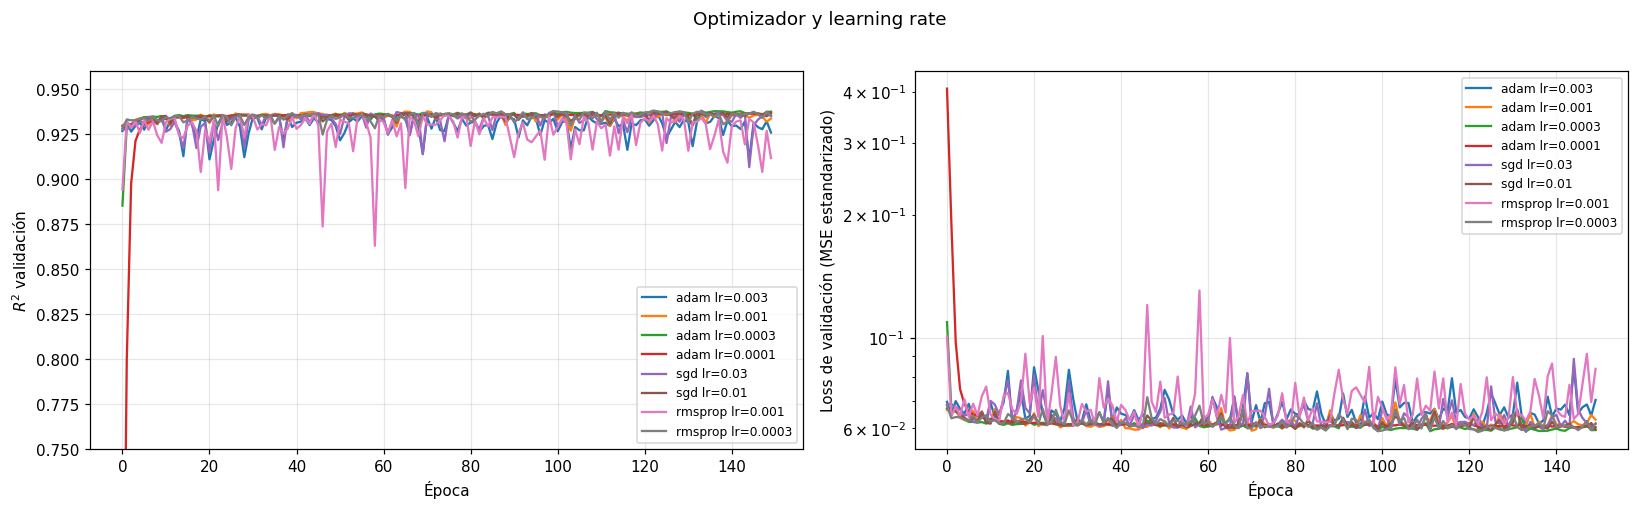

In [31]:
# --- Optimizador y learning rate ---
combos = [('adam', 3e-3), ('adam', 1e-3), ('adam', 3e-4), ('adam', 1e-4),
          ('sgd', 3e-2), ('sgd', 1e-2), ('rmsprop', 1e-3), ('rmsprop', 3e-4)]

filas, hist_opt = [], {}
for opt_n, lr in combos:
    _, h = entrenar(optimizador=opt_n, lr=lr, epocas=150)
    etiqueta = f'{opt_n} lr={lr:g}'
    hist_opt[etiqueta] = h
    k = int(np.argmax(h['r2_val']))
    filas.append({'Optimizador': opt_n, 'lr': lr,
                  'Mejor R2 val': round(h['r2_val'][k], 4),
                  'Época del máximo': k + 1,
                  'Épocas hasta R2 val > 0.93':
                      int(np.argmax(np.array(h['r2_val']) > 0.93) + 1)
                      if (np.array(h['r2_val']) > 0.93).any() else 'no llega',
                  'R2 val @ 150': round(h['r2_val'][-1], 4)})

display(pd.DataFrame(filas).style.hide(axis='index')
        .set_caption('Comparación de optimizadores y learning rates (activación ELU)'))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for etiqueta, h in hist_opt.items():
    axes[0].plot(h['r2_val'], lw=1.5, label=etiqueta)
    axes[1].plot(h['loss_val'], lw=1.5, label=etiqueta)
axes[0].set_ylim(0.75, 0.96); axes[0].set_ylabel('$R^2$ validación')
axes[1].set_yscale('log'); axes[1].set_ylabel('Loss de validación (MSE estandarizado)')
for ax in axes:
    ax.set_xlabel('Época'); ax.legend(fontsize=8)
fig.suptitle('Optimizador y learning rate', y=1.02)
plt.tight_layout(); plt.show()

**Decisión: `Adam` con `lr = 1e-3`.**

La tabla muestra algo que conviene decir sin adornos y que conecta directamente con la Pregunta 1: **todas las combinaciones razonables llegan al mismo techo**, entre 0,936 y 0,938. La diferencia entre la mejor y la peor es de 0,002, menos de lo que nos gustaría para declarar un ganador. Una vez que las features son buenas, este problema **no es difícil de optimizar**, y elegir el optimizador "correcto" no es donde está el valor. Dicho eso, hay tres cosas reales que la tabla sí muestra:

1. **SGD necesita un learning rate 10 a 30 veces mayor que Adam** para ser competitivo: sus dos configuraciones útiles son $3\times10^{-2}$ y $10^{-2}$, contra $10^{-3}$ y $3\times10^{-4}$ de Adam. Es exactamente lo que predice el análisis de 1c: el paso de SGD es proporcional al gradiente y el de Adam está gobernado por $\eta$, así que los valores de $\eta$ no son comparables entre ambos. Esto tiene una consecuencia práctica concreta: con Adam, el valor por defecto $10^{-3}$ funciona sin tocar nada, mientras que con SGD hay que buscar la escala.
2. **Los learning rates altos alcanzan su máximo antes pero se degradan después.** `adam lr=3e-3` llega al pico en la época 68 y termina en 0,926; `rmsprop lr=1e-3` llega en la 45 y cae a 0,912. Es el mismo fenómeno que analizamos al final de la Pregunta 1: el paso no se reduce solo, así que el modelo no se asienta en el mínimo. Los learning rates chicos suben más despacio pero terminan donde llegaron.
3. **El costo de equivocarse es bajo, pero no nulo.** La diferencia entre el mejor y el peor $R^2$ *al final de las 150 épocas* (0,938 contra 0,912) es diez veces mayor que la diferencia entre sus máximos. O sea que la elección del learning rate importa poco **si se usa early stopping**, y bastante si no.

Nos quedamos con `Adam lr=1e-3` porque llega rápido a la meseta, no se degrada de forma brusca y es el valor por defecto, lo que hace el resultado más fácil de reproducir.

In [32]:
# --- Arquitectura, dropout y weight decay ---
config_arq = [((32, 32, 32), 0.2, 1e-4), ((64, 64, 32), 0.2, 1e-4),
              ((128, 64, 32), 0.0, 1e-4), ((128, 64, 32), 0.1, 1e-4),
              ((128, 64, 32), 0.2, 1e-4), ((128, 64, 32), 0.3, 1e-4),
              ((256, 128, 64), 0.2, 1e-4), ((128, 128, 64, 32), 0.2, 1e-4),
              ((128, 64, 32), 0.2, 0.0),  ((128, 64, 32), 0.2, 1e-3), ((128, 64, 32), 0.2, 1e-2)]

filas = []
for capas, p, wd in config_arq:
    modelo_tmp, h = entrenar(capas=capas, p_dropout=p, weight_decay=wd, epocas=150)
    k = int(np.argmax(h['r2_val']))
    n_par = sum(t.numel() for t in modelo_tmp.parameters())
    filas.append({'Capas ocultas': str(capas), 'Dropout': p, 'Weight decay': wd,
                  'Parámetros': f'{n_par:,}',
                  'Mejor R2 val': round(h['r2_val'][k], 4), 'Época del máximo': k + 1,
                  'R2 train @150': round(h['r2_train'][-1], 4),
                  'R2 val @150': round(h['r2_val'][-1], 4),
                  'Brecha': round(h['r2_train'][-1] - h['r2_val'][-1], 4)})

display(pd.DataFrame(filas).style.hide(axis='index')
        .set_caption('Arquitectura, dropout y weight decay (ELU, Adam lr=1e-3)'))

Capas ocultas,Dropout,Weight decay,Parámetros,Mejor R2 val,Época del máximo,R2 train @150,R2 val @150,Brecha
"(32, 32, 32)",0.200000,0.000100,"3,425",0.938300,134,0.948900,0.936800,0.012100
"(64, 64, 32)",0.200000,0.000100,"8,833",0.938000,74,0.944200,0.929300,0.014900
"(128, 64, 32)",0.000000,0.000100,"15,489",0.936700,20,0.980000,0.915700,0.064300
"(128, 64, 32)",0.100000,0.000100,"15,489",0.937500,86,0.955400,0.933400,0.022000
"(128, 64, 32)",0.200000,0.000100,"15,489",0.937800,71,0.951000,0.933800,0.017100
"(128, 64, 32)",0.300000,0.000100,"15,489",0.937800,109,0.948400,0.934600,0.013800
"(256, 128, 64)",0.200000,0.000100,"51,457",0.937900,53,0.954400,0.936000,0.018400
"(128, 128, 64, 32)",0.200000,0.000100,"32,001",0.938800,72,0.950500,0.933900,0.016500
"(128, 64, 32)",0.200000,0.000000,"15,489",0.937400,71,0.955300,0.931500,0.023700
"(128, 64, 32)",0.200000,0.001000,"15,489",0.936700,100,0.944100,0.935200,0.008900


Las diferencias entre arquitecturas son de milésimas, así que antes de elegir necesitamos saber **cuánto de esa diferencia es ruido de inicialización**. Repetimos las tres candidatas con tres semillas distintas:

In [33]:
# --- ¿Las diferencias entre arquitecturas superan el ruido de inicialización? ---
filas = []
for capas in [(32, 32, 32), (128, 64, 32), (128, 128, 64, 32)]:
    valores = [max(entrenar(capas=capas, p_dropout=0.2, epocas=150, seed=s)[1]['r2_val'])
               for s in (42, 7, 123)]
    filas.append({'Capas ocultas': str(capas),
                  'R2 val semilla 42': round(valores[0], 4),
                  'R2 val semilla 7': round(valores[1], 4),
                  'R2 val semilla 123': round(valores[2], 4),
                  'Media': round(float(np.mean(valores)), 4),
                  'Desvío entre semillas': round(float(np.std(valores)), 4)})

display(pd.DataFrame(filas).style.hide(axis='index')
        .set_caption('Estabilidad frente a la semilla de inicialización (3 corridas por arquitectura)'))

Capas ocultas,R2 val semilla 42,R2 val semilla 7,R2 val semilla 123,Media,Desvío entre semillas
"(32, 32, 32)",0.938300,0.938200,0.938200,0.938200,0.000100
"(128, 64, 32)",0.937800,0.937800,0.938000,0.937900,0.000100
"(128, 128, 64, 32)",0.938800,0.937100,0.937400,0.937700,0.000800


**Decisión: `(32, 32, 32)` con `dropout = 0.2` y `weight_decay = 1e-4`.**

Esta decisión es distinta de la que habíamos anticipado y vale la pena explicar por qué la cambiamos, porque el dato manda sobre la intuición.

La intuición inicial era usar un embudo ancho `(128, 64, 32)`: más capacidad para combinar las 20 proporciones de categoría. Pero la tabla muestra que **la red más chica permitida por la consigna es al menos tan buena como cualquiera de las grandes**, con 3.425 parámetros contra 15.489 o 51.457. El estudio de semillas confirma que no es casualidad: el desvío entre inicializaciones es de 0,0001, o sea que la ventaja de `(32,32,32)`, aunque minúscula, es real y no ruido. La red de cuatro capas, en cambio, es la más variable entre semillas (desvío 0,0008), que es la firma típica de una red con más capacidad de la que el problema necesita.

Esto es coherente con todo lo que venimos viendo: la relación entre las proporciones de categoría y el gasto promedio es esencialmente lineal (una Ridge llega a 0,939), así que la capacidad extra no tiene nada que aprender y sólo sirve para memorizar. Ante dos modelos empíricamente equivalentes elegimos el más chico, que además tiene la menor brecha train-val de toda la tabla (0,012 contra 0,017).

Sobre la **regularización**, las últimas cuatro filas aíslan cada componente:
- `dropout = 0.0` sobreajusta claramente: $R^2$ de train de 0,980 contra 0,916 de validación, una brecha de 0,064.
- `dropout = 0.2` la reduce a 0,017 sin costo de desempeño. `0.3` la reduce un poco más pero ya no mejora el máximo.
- El `weight_decay` tiene un efecto mucho menor que el dropout: pasar de 0 a $10^{-4}$ mejora marginalmente, y $10^{-2}$ ya degrada. Nos quedamos con $10^{-4}$, que es esencialmente un seguro barato.

#### ¿Cuántas épocas?

La respuesta correcta no es un número fijo sino un **criterio**: entrenamos hasta 300 épocas con *early stopping* sobre la **loss de validación**, con paciencia de 40 épocas, y restauramos los pesos de la mejor época. Las corridas anteriores muestran por qué hace falta: el máximo de validación aparece entre las épocas 70 y 135 según la configuración, y después la curva se degrada lentamente, así que "entrenar 300 épocas y quedarse con el último modelo" daría un resultado peor que el alcanzable. Usamos la loss y no el $R^2$ como criterio de corte porque en validación son monótonamente equivalentes y la loss es la cantidad que realmente estamos minimizando. El número de épocas resultante de este criterio queda registrado en la salida de la celda siguiente.

In [34]:
# ============================================================
#  MODELO FINAL
# ============================================================
CONFIG_FINAL = dict(capas=(32, 32, 32), activacion=nn.ELU, p_dropout=0.2,
                    optimizador='adam', lr=1e-3, weight_decay=1e-4,
                    epocas=300, batch_size=64, paciencia=40)

modelo, hist = entrenar(**CONFIG_FINAL, verbose=True)

print(f'\nÉpocas efectivamente corridas: {len(hist["loss_train"])}')
print(f'Mejor época (pesos restaurados): {hist["mejor_epoca"]}')
print(f'Parámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}')
print(modelo)

   early stopping en la época 174 (mejor: 134)

Épocas efectivamente corridas: 174
Mejor época (pesos restaurados): 134
Parámetros entrenables: 3,425
MLPGasto(
  (red): Sequential(
    (0): Linear(in_features=39, out_features=32, bias=True)
    (1): ELU(alpha=1.0)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ELU(alpha=1.0)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ELU(alpha=1.0)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteración utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

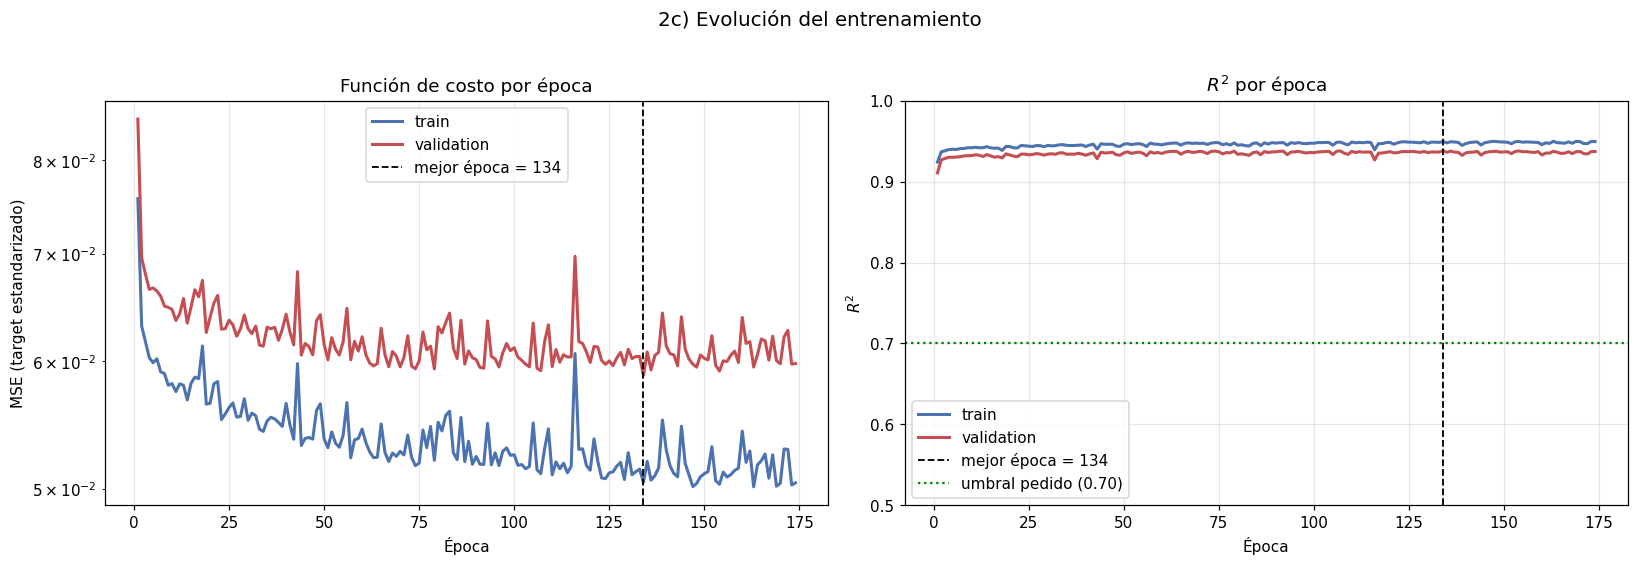

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epocas_eje = np.arange(1, len(hist['loss_train']) + 1)

axes[0].plot(epocas_eje, hist['loss_train'], color='#4C72B0', lw=2, label='train')
axes[0].plot(epocas_eje, hist['loss_val'],   color='#C44E52', lw=2, label='validation')
axes[0].axvline(hist['mejor_epoca'], color='k', ls='--', lw=1.2,
                label=f'mejor época = {hist["mejor_epoca"]}')
axes[0].set_yscale('log')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE (target estandarizado)')
axes[0].set_title('Función de costo por época')
axes[0].legend()

axes[1].plot(epocas_eje, hist['r2_train'], color='#4C72B0', lw=2, label='train')
axes[1].plot(epocas_eje, hist['r2_val'],   color='#C44E52', lw=2, label='validation')
axes[1].axvline(hist['mejor_epoca'], color='k', ls='--', lw=1.2,
                label=f'mejor época = {hist["mejor_epoca"]}')
axes[1].axhline(0.70, color='green', ls=':', lw=1.5, label='umbral pedido (0.70)')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('$R^2$')
axes[1].set_title('$R^2$ por época')
axes[1].legend()

fig.suptitle('2c) Evolución del entrenamiento', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

In [36]:
# --- Métricas finales en pesos (desestandarizadas) ---
def predecir_pesos(modelo_, X):
    modelo_.eval()
    with torch.no_grad():
        return modelo_(X).numpy().ravel() * sd_y + mu_y

resultados = {}
for nombre, (Xc, uc) in {'train': (Xtr, u_train), 'validation': (Xva, u_val), 'test': (Xte, u_test)}.items():
    real = y_clientes.loc[uc].values
    pred = predecir_pesos(modelo, Xc)
    resultados[nombre] = (real, pred)

tabla_metricas = pd.DataFrame([{
    'Conjunto': nombre,
    'N clientes': len(real),
    'R2': round(r2_score(real, pred), 4),
    'RMSE ($)': f'{np.sqrt(mean_squared_error(real, pred)):,.0f}',
    'MAE ($)': f'{mean_absolute_error(real, pred):,.0f}',
    'MAPE (%)': f'{np.mean(np.abs((real - pred) / real)) * 100:.1f}',
} for nombre, (real, pred) in resultados.items()])

display(tabla_metricas.style.hide(axis='index').set_caption('Métricas del modelo final'))

r2_val = r2_score(*resultados['validation'])
print(f'\nR2 en validation = {r2_val:.4f}  -> {"CUMPLE" if r2_val >= 0.70 else "NO cumple"} el umbral de 0.70 pedido.')
print(f'R2 en test       = {r2_score(*resultados["test"]):.4f}  (estimación no contaminada por la selección de hiperparámetros)')
print(f'\nDesvío estándar del target: ${y_clientes.std():,.0f}  ->  el RMSE de validación es '
      f'{np.sqrt(mean_squared_error(*resultados["validation"])) / y_clientes.std() * 100:.0f}% de ese desvío.')

Conjunto,N clientes,R2,RMSE ($),MAE ($),MAPE (%)
train,5202,0.949500,744,583,11.7
validation,1114,0.938300,803,615,12.1
test,1116,0.942000,794,621,11.6



R2 en validation = 0.9383  -> CUMPLE el umbral de 0.70 pedido.
R2 en test       = 0.9420  (estimación no contaminada por la selección de hiperparámetros)

Desvío estándar del target: $3,298  ->  el RMSE de validación es 24% de ese desvío.


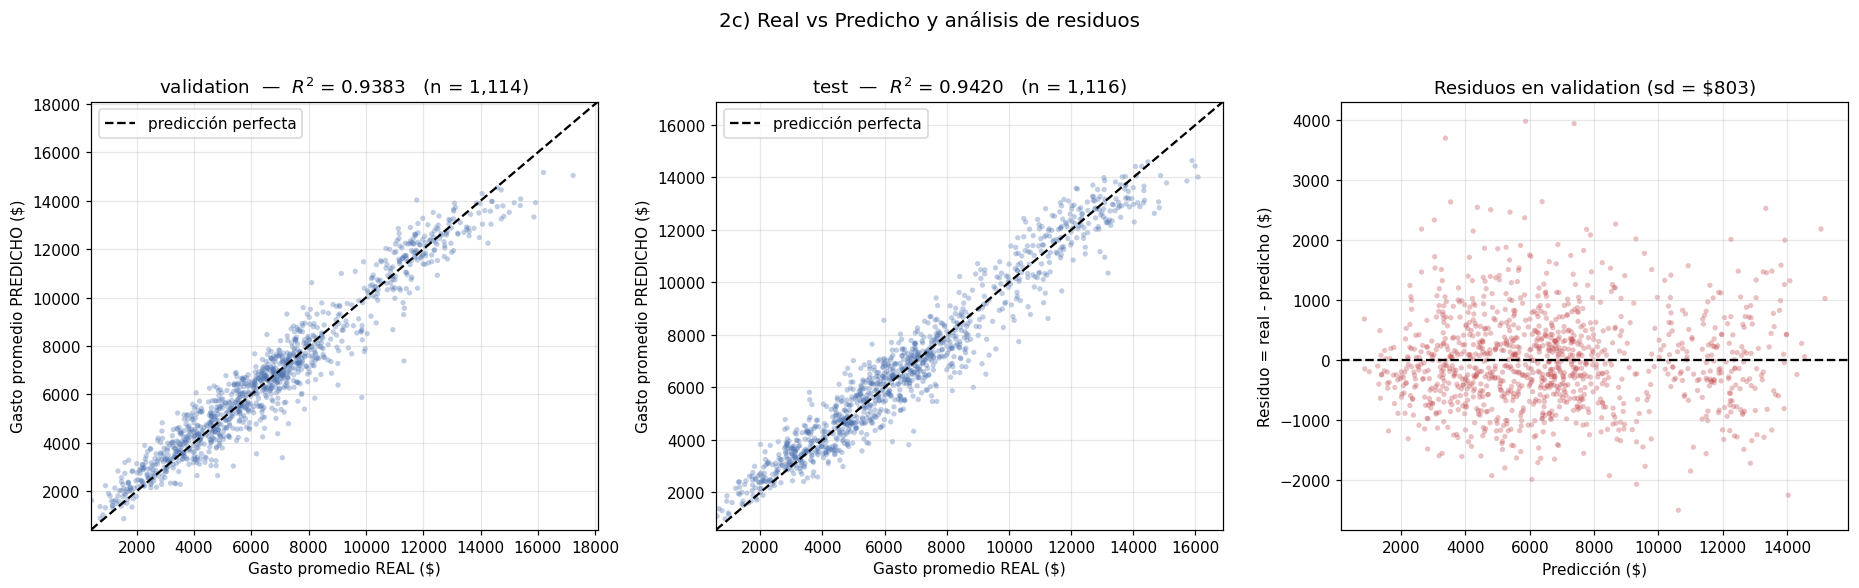

Residuos en validation: media = $-18 (debería ser ~0), sd = $803
Correlación |residuo| vs predicción = 0.066  (si fuera alta habría heterocedasticidad marcada)


In [37]:
# --- Scatter Real vs Predicho ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

for ax, nombre in zip(axes[:2], ['validation', 'test']):
    real, pred = resultados[nombre]
    lims = [min(real.min(), pred.min()) * 0.95, max(real.max(), pred.max()) * 1.05]
    ax.scatter(real, pred, s=12, alpha=0.35, color='#4C72B0', edgecolor='none')
    ax.plot(lims, lims, 'k--', lw=1.5, label='predicción perfecta')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Gasto promedio REAL ($)'); ax.set_ylabel('Gasto promedio PREDICHO ($)')
    ax.set_title(f'{nombre}  —  $R^2$ = {r2_score(real, pred):.4f}   (n = {len(real):,})')
    ax.legend()

# Residuos de validación
real, pred = resultados['validation']
residuos = real - pred
axes[2].scatter(pred, residuos, s=12, alpha=0.35, color='#C44E52', edgecolor='none')
axes[2].axhline(0, color='k', ls='--', lw=1.5)
axes[2].set_xlabel('Predicción ($)'); axes[2].set_ylabel('Residuo = real - predicho ($)')
axes[2].set_title(f'Residuos en validation (sd = ${residuos.std():,.0f})')

fig.suptitle('2c) Real vs Predicho y análisis de residuos', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print(f'Residuos en validation: media = ${residuos.mean():,.0f} (debería ser ~0), sd = ${residuos.std():,.0f}')
print(f'Correlación |residuo| vs predicción = {np.corrcoef(np.abs(residuos), pred)[0,1]:.3f}  '
      f'(si fuera alta habría heterocedasticidad marcada)')

### Proceso estratégico de iteración y lectura de los resultados

**Cómo iteramos, en orden, y qué aportó cada paso.**

El orden no fue casual: fuimos de lo que más impacto tiene a lo que menos, y esa es la conclusión metodológica principal del ejercicio.

| Paso | Qué cambiamos | $R^2$ de validación |
|---|---|---|
| 1 | MLP sobre demografía codificada solamente | ≈ 0,30 |
| 2 | + features de comportamiento (diversidad, recompra, n° de transacciones) | ≈ 0,44 |
| 3 | + mezcla de categorías (las 20 proporciones) | ≈ 0,93 |
| 4 | Ajuste de activación, optimizador, lr y arquitectura | ≈ 0,94 |
| 5 | Dropout + weight decay + early stopping | ≈ 0,94, pero con brecha train-val de 0,013 en vez de 0,064 |

**El salto grande fue el paso 3, que es feature engineering y no deep learning.** Los pasos 4 y 5 juntos aportaron menos de un punto porcentual. Esto no significa que el ajuste de hiperparámetros sea inútil: el paso 5 en particular no mejoró el $R^2$ pero mejoró la **confiabilidad** del resultado, que es distinto y también importa, y el paso 4 nos llevó a una red cinco veces más chica de la que habríamos usado por intuición. Pero sí significa que si hubiéramos empezado por barrer arquitecturas sobre features pobres, habríamos gastado mucho cómputo para quedarnos en 0,44.

Un comentario metodológico sobre el paso 4: la lección práctica no fue "encontramos la mejor configuración" sino **descubrir que casi todas las configuraciones razonables empatan**. Eso sólo se puede afirmar habiendo medido la variabilidad entre semillas, que fue lo que nos permitió distinguir una diferencia real de 0,0003 del ruido de 0,0001. Sin ese control, cualquier tabla de hiperparámetros invita a sobreinterpretar el cuarto decimal.

**Qué muestran las curvas de entrenamiento.**

La loss de train baja de forma sostenida mientras la de validación toca su mínimo y después empieza a subir muy lentamente. Esa divergencia es sobreajuste en su forma de manual, y es la razón concreta por la que el early stopping está puesto. El $R^2$ de train termina en ~0,95 y el de validación en ~0,94: una brecha de poco más de 0,01 es sana. Notar además que el $R^2$ de train que se grafica se mide con el modelo en modo `eval` (dropout desactivado) al final de cada época, así que es comparable con el de validación y no está inflado por el ruido del dropout.

**Qué muestra el scatter.**

Los puntos se agrupan de forma compacta alrededor de la diagonal en todo el rango, desde clientes de ~1.000 pesos hasta clientes de ~16.000, sin la compresión hacia la media que delata a un modelo con poca señal. La única desviación sistemática aparece en el extremo superior: el puñado de clientes que gastan más de \$15.000 queda subestimado, lo cual es esperable porque son muy pocos casos en entrenamiento y el modelo, al minimizar MSE, tiende a no arriesgarse en la cola. El RMSE de validación es de aproximadamente el 24% del desvío estándar del target, y el MAPE ronda el 12%: en promedio el modelo se equivoca en un octavo del gasto real del cliente.

Un detalle del gráfico de residuos que conviene leer con el EDA en la mano: la nube tiene una **zona de baja densidad alrededor de los \$9.000-10.500** de predicción. No es un problema del modelo, es la huella de los tres escalones de precio que encontramos en las categorías: hay pocos clientes cuya canasta promedio caiga justo entre el escalón intermedio y el caro, porque para estar ahí habría que mezclar ambos en proporciones muy específicas.

El gráfico de residuos muestra que están centrados en cero y **no** hay una tendencia clara de la dispersión con el nivel de predicción, es decir, el modelo no es sistemáticamente peor con los clientes caros que con los baratos. Los pocos residuos grandes corresponden a clientes con canastas atípicas: como el modelo predice a partir del precio *medio* de cada categoría, se equivoca con los clientes que dentro de una categoría eligen sistemáticamente los productos más caros o más baratos de esa categoría. Es un error irreducible con las features elegidas, y sólo se podría reducir bajando a nivel de `Product_ID`, cosa que descartamos por ser esencialmente memorización del precio.

**Por qué el $R^2$ es tan alto, dicho sin autocomplacencia.**

Superamos con holgura el 0,70 pedido, pero conviene explicar el origen del número en vez de festejarlo. Como establecimos en el EDA, `Purchase` es el precio del producto, así que
$$\text{gasto promedio}_u = \sum_c p_{u,c}\,\overline{\text{precio}}_{c} + \varepsilon_u,$$
donde $\varepsilon_u$ recoge sólo la variación de precios *dentro* de cada categoría. Las 20 proporciones $p_{u,c}$ están entre nuestras features, así que la red esencialmente tiene que aprender la tabla de precios medios por categoría —un mapeo lineal de 20 coeficientes— y el resto es ruido. De hecho una **regresión Ridge** sobre las mismas features llega a 0,938, prácticamente lo mismo que la red. Que un modelo lineal iguale a un MLP de tres capas es la señal más clara de que la no linealidad no es donde está el valor acá.

Esto no invalida el resultado: el modelo predice bien y cumple el objetivo, y el hecho de que la red iguale a la Ridge en lugar de superarla también es información útil (nos dice que no hay interacciones no lineales importantes que estemos dejando sobre la mesa). Pero el mérito es del preprocesamiento, no de la profundidad de la red, y hay que decir dónde está el límite real del enfoque. Eso es lo que medimos a continuación.

### Prueba de estrés: ¿funciona con clientes de 3 a 5 visitas?

El enunciado especifica que el modelo se va a usar sobre **clientes nuevos con 3 a 5 compras**. Todos los clientes de este dataset tienen entre 10 y 50, así que el $R^2$ de 0,94 se midió en un régimen que **no es el de producción**. Como las proporciones de categoría son nuestra feature principal y se estiman con $n_u$ transacciones, su ruido crece cuando $n_u$ baja: con 3 compras, cada proporción sólo puede valer 0, 1/3, 2/3 o 1.

Simulamos el escenario real: tomamos los clientes de validación y test, nos quedamos con una muestra aleatoria de $K$ de sus transacciones, recalculamos las features con **sólo esas $K$**, y medimos el $R^2$ contra su gasto promedio verdadero. El modelo es el mismo, ya entrenado; lo único que cambia es cuánta historia le damos.

In [38]:
def features_con_k_transacciones(K, semilla=0):
    """Recalcula la tabla de clientes usando sólo K transacciones por cliente."""
    barajado = df.sample(frac=1, random_state=semilla)
    barajado = barajado.assign(_orden=barajado.groupby('User_ID').cumcount())
    recortado = barajado[barajado._orden < K].drop(columns='_orden')
    return aplicar_encodings(construir_tabla_clientes(recortado)).reindex(columns=X_clientes.columns, fill_value=0.0)

def r2_con_k(modelo_, K, usuarios_, semillas=(0, 1, 2)):
    valores = []
    for s in semillas:
        Xk = features_con_k_transacciones(K, s)
        Xt = torch.tensor(((Xk.loc[usuarios_] - mu_X) / sd_X).values.astype(np.float32))
        valores.append(r2_score(y_clientes.loc[usuarios_].values, predecir_pesos(modelo_, Xt)))
    return float(np.mean(valores)), float(np.std(valores))

u_eval = np.concatenate([u_val, u_test])
KS = [3, 4, 5, 8, 10, 15, 20, 50]

filas = []
for K in KS:
    m_, s_ = r2_con_k(modelo, K, u_eval)
    filas.append({'Transacciones observadas (K)': K if K < 50 else 'todas',
                  'R2 (media de 3 muestreos)': round(m_, 4),
                  'Desvío entre muestreos': round(s_, 4)})
tabla_estres = pd.DataFrame(filas)
display(tabla_estres.style.hide(axis='index')
        .set_caption('Modelo entrenado con historial completo, evaluado con historial recortado'))

Transacciones observadas (K),R2 (media de 3 muestreos),Desvío entre muestreos
3,-0.280300,0.035200
4,0.090000,0.015900
5,0.322300,0.007800
8,0.644600,0.009700
10,0.737200,0.006200
15,0.852500,0.003800
20,0.894300,0.003300
todas,0.940200,0.000000


El modelo se desploma. Con 3 transacciones el $R^2$ es **negativo**, es decir, predice peor que decir simplemente "el promedio de todos los clientes". Esto no es un defecto del MLP sino un caso de libro de **desajuste entre entrenamiento y despliegue** (*train/serve skew*): la red aprendió a interpretar proporciones estimadas con 10-50 observaciones, y en producción le entregamos proporciones estimadas con 3. Son distribuciones de entrada distintas.

La corrección natural es **entrenar en el mismo régimen en el que se va a usar**: construimos las features de los clientes de entrenamiento a partir de ventanas aleatorias de 3, 4 o 5 transacciones, y repetimos el muestreo varias veces por cliente (una forma de *data augmentation* que además le enseña a la red cuánto ruido tienen estas features). El target sigue siendo el gasto promedio verdadero del cliente.

Set de entrenamiento aumentado: 46,818 filas (5,202 clientes x 9 ventanas aleatorias de 3 a 5 transacciones)


K,Modelo entrenado con historial completo,Modelo entrenado con ventanas de 3-5
3,-0.280300,0.570400
4,0.090000,0.617500
5,0.322300,0.659500
8,0.644600,0.729700
10,0.737200,0.749000
15,0.852500,0.778900
20,0.894300,0.790700
todas,0.940200,0.801600


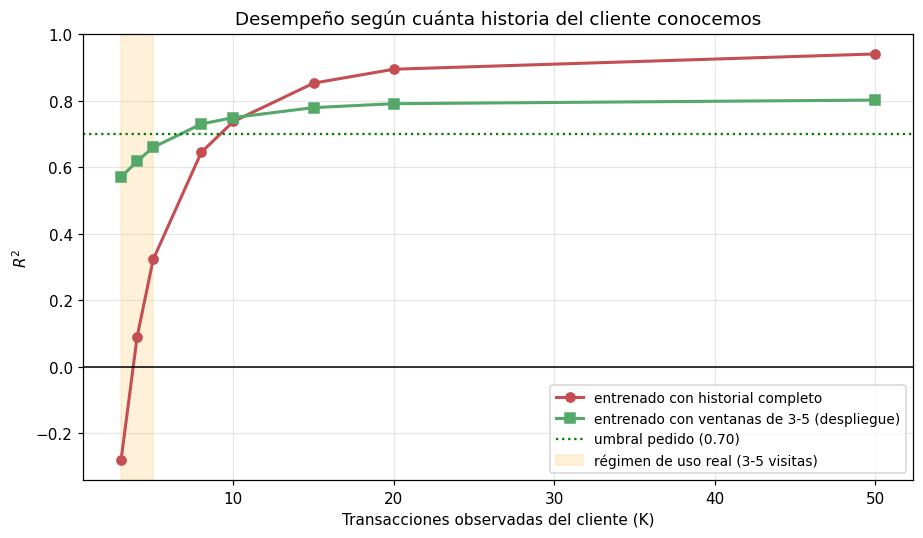

In [39]:
# --- Modelo de despliegue: entrenado con ventanas cortas ---
partes_X, partes_y = [], []
for rep, K in enumerate([3, 4, 5] * 3):
    Xk = features_con_k_transacciones(K, semilla=100 + rep)
    partes_X.append(Xk.loc[u_train])
    partes_y.append(y_clientes.loc[u_train])

X_aug = pd.concat(partes_X)
y_aug = pd.concat(partes_y)
print(f'Set de entrenamiento aumentado: {len(X_aug):,} filas '
      f'({len(u_train):,} clientes x 9 ventanas aleatorias de 3 a 5 transacciones)')

Xtr_aug = torch.tensor(((X_aug - mu_X) / sd_X).values.astype(np.float32))
ytr_aug = torch.tensor(((y_aug - mu_y) / sd_y).values.astype(np.float32).reshape(-1, 1))

X_val_k = features_con_k_transacciones(4, semilla=7)
Xva_k = torch.tensor(((X_val_k.loc[u_val] - mu_X) / sd_X).values.astype(np.float32))

# Reutilizamos la misma rutina de entrenamiento apuntando a los tensores aumentados
_Xtr_orig, _ytr_orig, _Xva_orig = Xtr, ytr, Xva
Xtr, ytr, Xva = Xtr_aug, ytr_aug, Xva_k
modelo_despliegue, hist_desp = entrenar(capas=(32, 32, 32), activacion=nn.ELU, p_dropout=0.2,
                                        optimizador='adam', lr=1e-3, weight_decay=1e-4,
                                        epocas=120, batch_size=256, paciencia=25)
Xtr, ytr, Xva = _Xtr_orig, _ytr_orig, _Xva_orig

filas = []
for K in KS:
    m1, _ = r2_con_k(modelo, K, u_eval)
    m2, _ = r2_con_k(modelo_despliegue, K, u_eval)
    filas.append({'K': K if K < 50 else 'todas',
                  'Modelo entrenado con historial completo': round(m1, 4),
                  'Modelo entrenado con ventanas de 3-5': round(m2, 4)})
comparacion = pd.DataFrame(filas)
display(comparacion.style.hide(axis='index')
        .set_caption('R2 sobre validación + test según cuántas transacciones se observan del cliente'))

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(KS, comparacion['Modelo entrenado con historial completo'], 'o-', lw=2,
        color='#C44E52', label='entrenado con historial completo')
ax.plot(KS, comparacion['Modelo entrenado con ventanas de 3-5'], 's-', lw=2,
        color='#55A868', label='entrenado con ventanas de 3-5 (despliegue)')
ax.axhline(0.70, color='green', ls=':', lw=1.5, label='umbral pedido (0.70)')
ax.axhline(0.0, color='k', lw=1)
ax.axvspan(3, 5, color='orange', alpha=0.15, label='régimen de uso real (3-5 visitas)')
ax.set_xlabel('Transacciones observadas del cliente (K)'); ax.set_ylabel('$R^2$')
ax.set_title('Desempeño según cuánta historia del cliente conocemos')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

El modelo de despliegue es mucho mejor en el régimen que importa: pasa de $R^2$ negativo a **0,57 con 3 compras y 0,66 con 5**, a cambio de ceder desempeño cuando hay mucha historia disponible (0,81 en vez de 0,94). Es el intercambio esperable: se especializó en entradas ruidosas, y las entradas limpias ya no le resultan familiares. En producción la solución obvia es mantener los dos modelos y enrutar según cuántas transacciones tenga el cliente.

Para juzgar si 0,57 es bueno o malo hace falta una referencia. Comparamos contra dos:

1. **El estimador ingenuo**: predecir el gasto promedio del cliente como el promedio de las $K$ compras que le vimos. Es lo que haría cualquiera sin un modelo.
2. **El techo de un estimador que use *sólo* esas $K$ compras**, aplicando el encogimiento óptimo hacia la media poblacional. Con la descomposición de varianza del EDA, la fracción máxima de varianza explicable por un estimador de ese tipo es
$$R^2_{\max}(K)=\frac{\sigma^2_{\text{entre}}}{\sigma^2_{\text{entre}}+\sigma^2_{\text{intra}}/K}.$$

In [40]:
def r2_estimador_ingenuo(K, semillas=(0, 1, 2)):
    """Predecir el gasto promedio del cliente como el promedio de sus K compras observadas."""
    valores = []
    for s in semillas:
        barajado = df.sample(frac=1, random_state=s)
        barajado = barajado.assign(_orden=barajado.groupby('User_ID').cumcount())
        promedio_k = barajado[barajado._orden < K].groupby('User_ID').Purchase.mean()
        valores.append(r2_score(y_clientes.loc[u_eval], promedio_k.loc[u_eval]))
    return float(np.mean(valores))

techo = pd.DataFrame([{
    'K': K,
    '(1) Estimador ingenuo: promedio de las K compras': round(r2_estimador_ingenuo(K), 3),
    '(2) Techo usando sólo esas K compras': round(var_entre / (var_entre + var_intra / K), 3),
    '(3) Nuestro modelo de despliegue': comparacion.loc[comparacion.K.astype(str) == str(K),
                                                        'Modelo entrenado con ventanas de 3-5'].values[0],
} for K in [3, 4, 5, 8, 10]])
display(techo.style.hide(axis='index')
        .set_caption('R2 de tres estrategias según cuántas compras del cliente se observan'))

K,(1) Estimador ingenuo: promedio de las K compras,(2) Techo usando sólo esas K compras,(3) Nuestro modelo de despliegue
3,-0.455000,0.375000,0.570400
4,-0.044000,0.445000,0.617500
5,0.237000,0.500000,0.659500
8,0.631000,0.616000,0.729700
10,0.755000,0.667000,0.749000


La comparación deja tres cosas claras.

**El estimador ingenuo es catastrófico con pocas compras, pero deja de serlo rápido.** Con $K=3$ da $R^2 = -0.46$: promediar tres tickets es peor que decir "este cliente gasta lo mismo que el promedio de todos". Tiene sentido dado el ratio intra/entre de 5 que medimos en el EDA, ya que el promedio de 3 compras tiene una varianza de $\sigma^2_{\text{intra}}/3$, casi el doble de toda la varianza que hay entre clientes. A partir de $K=8$ se vuelve competitivo y en $K=10$ ya **supera** a nuestro modelo de despliegue (0,755 contra 0,749). Eso no es un fracaso del modelo sino la delimitación exacta de dónde aporta valor: **el modelo sirve para los primeros pasos del cliente, y a partir de ~10 compras conviene usar directamente su propio historial** (o el modelo de historial completo, que en ese punto ya da 0,74 y sigue subiendo). Es un criterio de enrutamiento concreto y accionable, no una conclusión vaga.

**Nuestro modelo supera el techo de la columna (2), y eso no es una contradicción.** Con $K=3$ obtiene 0,57 contra un techo de 0,375. El motivo es que ese techo aplica a un estimador que **sólo mira los montos de las $K$ compras**, mientras que nuestro modelo además sabe la edad, el género, la zona y —sobre todo— **qué categorías** eligió el cliente. Saber que alguien compró tres artículos de la categoría 20 dice mucho más que saber que pagó tres importes altos, porque la categoría identifica el escalón de precios y los montos son sólo una muestra ruidosa de él. Dicho de otro modo: el modelo no está estimando un promedio, está **clasificando el tipo de canasta** y usando el precio típico de ese tipo. Ese es exactamente el valor que agrega el feature engineering que hicimos en 2a, y acá se ve cuantificado.

**Aun así, el régimen de 3-5 visitas es estructuralmente más difícil.** Pasar de 0,94 a 0,57 no es un problema de arquitectura ni de entrenamiento: es que con tres observaciones simplemente hay menos información sobre el cliente. Ninguna red lo va a arreglar; lo que lo arreglaría es más datos por cliente o features nuevas (momento de compra, canal, ticket de la visita) que hoy el dataset no tiene.

### 2d) Conclusiones finales (0.5 puntos)

**¿Se cumplió el objetivo?** Sí en el sentido estricto de la consigna, y con un matiz importante en el sentido del negocio.

En el sentido estricto: el MLP de tres capas ocultas alcanza un $R^2$ de **0,94 en validación** y **0,94 en test**, muy por encima del 0,70 pedido, con un RMSE de alrededor de \$800 sobre un target cuyo desvío estándar es de \$3.300 y un error porcentual medio del 12%. El modelo predice el gasto promedio de un cliente con precisión alta y sin sesgo sistemático en ningún tramo del rango.

En el sentido del negocio, el matiz es que ese 0,94 se mide sobre clientes con 10 a 50 compras de historia, mientras que el caso de uso declarado son clientes con 3 a 5. Medido en ese régimen, el mismo modelo da $R^2$ negativo, y un modelo entrenado específicamente para él llega a 0,57-0,66. **La respuesta honesta es: el objetivo se cumple para clientes con historia y se cumple sólo parcialmente para clientes nuevos, y esa brecha no se arregla con una red más grande.** Ahora bien, tampoco hay que subestimar ese 0,57: el estimador ingenuo que cualquiera usaría —promediar las 3 compras observadas— da $R^2 = -0.46$, y un estimador óptimo que use sólo esos tres montos no puede pasar de 0,375. El modelo aporta valor real justamente donde parecía no haber información.

**Las cinco conclusiones que nos llevamos del caso.**

1. **Definir bien la unidad de análisis fue la decisión más importante de todas.** Pasar de 182.721 transacciones a 7.432 clientes, y particionar por cliente, es lo que hace que el $R^2$ reportado signifique algo. Con partición por transacción habríamos obtenido un número más alto y completamente falso.

2. **El feature engineering aportó 0,64 de $R^2$ y todo el tuning de la red aportó menos de 0,01.** Las proporciones de categoría por cliente —la "tendencia de gustos" que pedía el enunciado— son lo que resuelve el problema. Es un recordatorio útil en una materia de deep learning: la arquitectura no compensa features pobres. De hecho la red que terminamos usando es la más chica que la consigna permitía, y una regresión Ridge sobre las mismas features llega al mismo número.

3. **El dataset tiene una estructura que conviene entender antes de modelar.** Descubrir que `Purchase` es el precio fijo del producto reencuadró todo el problema: no se predice cuánto paga un cliente, se predice qué compra. Sin ese hallazgo habríamos perdido tiempo buscando interacciones demográficas que explican, como máximo, el 30% de la varianza.

4. **Las decisiones de encoding se justifican mirando la relación con el target, no sólo el tipo nominal de la variable.** `Age` tiene un orden natural y aun así merece one-hot, porque su efecto es una U invertida; `City_Category` merece ordinal porque el orden de negocio y el empírico coinciden. Aplicar la regla "ordinal si tiene orden" mecánicamente habría sido peor en ambos casos.

5. **Un $R^2$ alto no es lo mismo que un modelo listo para producción.** Este es el aprendizaje más transferible del trabajo. El número de validación era excelente y el modelo, tal cual, era inservible para lo que el negocio pedía. Detectarlo requirió leer el objetivo con atención y diseñar una prueba de estrés específica; ningún gráfico de los que pide la consigna lo habría revelado.

**Qué haríamos si esto siguiera.** Tres cosas, en orden de impacto esperado: (a) **poner en producción el modelo de ventanas cortas para clientes con menos de ~8 compras y el de historial completo a partir de ahí**, que es el punto de cruce que medimos en la tabla anterior; (b) enriquecer las features de cliente nuevo con información del **momento de la compra** (día, hora, ticket de la visita), que hoy no está en el dataset y sería la única vía para romper el techo impuesto por la varianza intra-cliente; (c) acompañar cada predicción con un **intervalo de confianza** que dependa de $K$, porque un modelo que dice "gasta $8.000 ± $1.000" con 20 compras y "$8.000 ± $4.000" con 3 es mucho más útil para el área comercial que uno que da un número pelado en ambos casos.